In [2]:
import os

import numpy as np

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from momentfm import MOMENTPipeline
import torch
from openai import OpenAI
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from transformers import AutoTokenizer, AutoModelForSequenceClassification

/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [3]:
ts_path = Path.cwd() / "data" / "time_series"

text_path = Path.cwd() / "data" / "text"

images_path = Path.cwd() / "images"
images_path.mkdir(parents=True, exist_ok=True)

csv_files = sorted(ts_path.glob("*.csv"))

In [4]:
print(f"{len(csv_files)} Ticker(s) found in {ts_path}")

ticker_to_df = {}
n_tickers = 100

for i, csv_file in enumerate(csv_files):

    if i >= n_tickers:
        break

    df = pd.read_csv(csv_file)
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce", utc=True)
    df = df.dropna(subset=["Date"]).sort_values("Date")
    df["Date"] = df["Date"].dt.tz_convert("UTC").dt.tz_localize(None)
    ticker_to_df[csv_file.stem] = df

4213 Ticker(s) found in /home/rodrigodog/latent_fusion/data/time_series


In [5]:
ticker_to_df[list(ticker_to_df.keys())[0]]

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2000-01-03 05:00:00,47.349391,47.462129,40.510035,43.290874,4674353,0.0,0.0
1,2000-01-04 05:00:00,40.960978,41.411927,38.931719,39.983929,4765083,0.0,0.0
2,2000-01-05 05:00:00,39.833601,39.983919,36.263611,37.503712,5758642,0.0,0.0
3,2000-01-06 05:00:00,37.052766,37.278241,34.948348,36.075714,2534434,0.0,0.0
4,2000-01-07 05:00:00,35.512038,39.645714,35.474461,39.082031,2819626,0.0,0.0
...,...,...,...,...,...,...,...,...
6343,2025-03-24 04:00:00,121.621613,124.166210,120.633714,121.711426,1557400,0.0,0.0
6344,2025-03-25 04:00:00,122.340082,122.779152,119.506107,120.254517,1605900,0.0,0.0
6345,2025-03-26 04:00:00,120.464074,120.883182,118.797617,119.645813,2652900,0.0,0.0
6346,2025-03-27 04:00:00,119.745596,120.074898,118.478292,118.717781,2075700,0.0,0.0


In [6]:
from features.technical import (
    sma, ema, hma, rsi, stochastic, atr, adx, macd, 
    awesome_oscillator, momentum, roc, bollinger_bands,
    rolling_volatility, stochastic_rsi, williams_r,
    keltner_channels, donchian_channels, bull_bear_power,
    parkinson_volatility, garman_klass_volatility
)

for ticker, df in ticker_to_df.items():
    close = df['Close']
    high = df['High']
    low = df['Low']
    volume = df['Volume']
    open_ = df['Open']
    
    df['sma_20'] = sma(close, 20)
    df['sma_50'] = sma(close, 50)
    df['ema_12'] = ema(close, 12)
    df['ema_26'] = ema(close, 26)
    df['hma_9'] = hma(close, 9)
    
    df['rsi_14'] = rsi(close, 14)
    
    macd_df = macd(close)
    df['macd'] = macd_df['macd']
    df['macd_signal'] = macd_df['signal']
    df['macd_hist'] = macd_df['histogram']
    
    stoch_df = stochastic(high, low, close)
    df['stoch_k'] = stoch_df['stoch_k']
    df['stoch_d'] = stoch_df['stoch_d']
    
    stoch_rsi_df = stochastic_rsi(close)
    df['stoch_rsi_k'] = stoch_rsi_df['stoch_rsi_k']
    df['stoch_rsi_d'] = stoch_rsi_df['stoch_rsi_d']
    
    df['atr_14'] = atr(high, low, close, 14)
    
    adx_df = adx(high, low, close, 14)
    df['plus_di'] = adx_df['plus_di']
    df['minus_di'] = adx_df['minus_di']
    df['adx'] = adx_df['adx']
    
    df['williams_r'] = williams_r(high, low, close, 14)
    
    df['momentum_10'] = momentum(close, 10)
    df['roc_10'] = roc(close, 10)
    
    df['awesome_osc'] = awesome_oscillator(high, low, 5, 34)
    
    bb_df = bollinger_bands(close, 20, 2.0)
    df['bb_upper'] = bb_df['bb_upper']
    df['bb_mid'] = bb_df['bb_mid']
    df['bb_lower'] = bb_df['bb_lower']
    df['bb_bandwidth'] = bb_df['bb_bandwidth']
    df['bb_percent_b'] = bb_df['bb_percent_b']
    
    kc_df = keltner_channels(high, low, close, 20, 10, 2.0)
    df['kc_upper'] = kc_df['kc_upper']
    df['kc_center'] = kc_df['kc_center']
    df['kc_lower'] = kc_df['kc_lower']
    df['kc_width'] = kc_df['kc_width']
    
    don_df = donchian_channels(high, low, 20)
    df['donchian_upper'] = don_df['donchian_upper']
    df['donchian_lower'] = don_df['donchian_lower']
    df['donchian_mid'] = don_df['donchian_mid']
    df['donchian_width'] = don_df['donchian_width']
    
    df['vol_rolling_20'] = rolling_volatility(close, 20)
    df['vol_parkinson'] = parkinson_volatility(high, low, 20)
    df['vol_garman_klass'] = garman_klass_volatility(open_, high, low, close, 20)
    
    bbp_df = bull_bear_power(high, low, close, 13)
    df['bull_power'] = bbp_df['bull_power']
    df['bear_power'] = bbp_df['bear_power']

/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [7]:
ticker_to_X = {}    
for ticker, df in ticker_to_df.items():
    X = df.drop(columns=['Date', 'Dividends', 'Stock Splits'])
    ticker_to_X[ticker] = X

In [8]:
n_channels = len(ticker_to_X[list(ticker_to_df.keys())[0]].columns) 
context_length = 30
# TODO: add various lengths and time horizons for comparison

In [9]:
ts_model = MOMENTPipeline.from_pretrained(
    "AutonLab/MOMENT-1-large",
    model_kwargs={
        "task_name": "embedding"
    },
)
ts_model.init()


/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/momentfm/models/moment.py:174: UserWarning: Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.
  warnings.warn("Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.")


In [15]:
import json
from datetime import timedelta

text_to_news_dates = {}
for text_file in sorted(text_path.glob("*.jsonl"))[:10]:
    ticker = text_file.stem.lower()
    news_dates = set()
    try:
        with open(text_file, 'r') as f:
            for line in f:
                entry = json.loads(line)
                date_str = entry.get('Date', '')
                if date_str:
                    news_dates.add(pd.to_datetime(date_str).normalize())
    except:
        pass
    text_to_news_dates[ticker] = news_dates
    if len(news_dates) > 0:
        print(f"{ticker}: {len(news_dates)} news dates")

print(f"\nLoaded news dates for {len(text_to_news_dates)} tickers\n")

ticker_to_embeddings = {}
sampling_interval = 7
batch_size = 16

for ticker, X in list(ticker_to_X.items())[:10]:
    n_samples = X.shape[0]
    df = ticker_to_df[ticker]
    dates = pd.to_datetime(df['Date']).values
    
    news_dates = text_to_news_dates.get(ticker, set())
    
    if len(news_dates) == 0:
        print(f"{ticker}: No news data, skipping")
        continue
    
    embeddings_list = []
    valid_indices = []
    
    indices = list(range(0, max(0, n_samples - context_length + 1)))
    
    for i in indices:
        current_date = pd.Timestamp(dates[i]).normalize()
        day_before = current_date - timedelta(days=1)
        
        if day_before in news_dates:
            valid_indices.append(i)
    
    print(f"{ticker}: {len(valid_indices)} dates with news previous day (out of {len(dates)} total)")
    
    if len(valid_indices) == 0:
        print(f"  Warning: No valid indices for {ticker}")
        continue
    
    for batch_idx in range(0, len(valid_indices), batch_size):
        batch_indices = valid_indices[batch_idx:batch_idx + batch_size]
        windows = []
        
        for i in batch_indices:
            window = X[i:i + context_length].astype(np.float32)
            if window.shape[0] < context_length:
                continue
            windows.append(window)
        
        if not windows:
            continue
        
        batch = np.array(windows)
        batch = torch.tensor(batch, dtype=torch.float32)
        
        with torch.no_grad():
            outputs = ts_model(x_enc=batch)
            embeddings_batch = outputs.embeddings.cpu().numpy()
        
        embeddings_list.extend(embeddings_batch)
    
    if embeddings_list:
        ticker_to_embeddings[ticker] = np.array(embeddings_list)
        print(f"  → Generated {len(embeddings_list)} embeddings\n")
    else:
        print(f"  → No embeddings generated\n")

ticker_to_embeddings_with_dates = {}
for ticker, embeddings in ticker_to_embeddings.items():
    df = ticker_to_df[ticker]
    dates = pd.to_datetime(df['Date']).values
    news_dates = text_to_news_dates.get(ticker, set())
    
    indices_list = []
    dates_list = []
    indices = list(range(0, max(0, len(dates) - context_length + 1)))
    
    for i in indices:
        current_date = pd.Timestamp(dates[i]).normalize()
        day_before = current_date - timedelta(days=1)
        if day_before in news_dates:
            indices_list.append(i)
            dates_list.append(current_date)
    
    ticker_to_embeddings_with_dates[ticker] = {
        'embeddings': embeddings,
        'dates': np.array(dates_list)
    }

print(f"✓ Generated embeddings for {len(ticker_to_embeddings)} tickers (filtered by news dates)")

a: 326 news dates
aa: 1054 news dates
aaau: 28 news dates
aacg: 46 news dates
aadr: 77 news dates
aal: 2312 news dates
aamc: 22 news dates
aame: 27 news dates
aan: 544 news dates
aaoi: 477 news dates

Loaded news dates for 10 tickers

a: 244 dates with news previous day (out of 6348 total)


/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an 

  → Generated 244 embeddings

aa: 804 dates with news previous day (out of 6348 total)


/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an 

  → Generated 804 embeddings

aaau: 16 dates with news previous day (out of 1664 total)


...

  → Generated 1734 embeddings

aame: 16 dates with news previous day (out of 6348 total)


/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


  → Generated 16 embeddings

aaoi: 363 dates with news previous day (out of 2894 total)


/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an 

  → Generated 363 embeddings

aaon: No news data, skipping
aap: No news data, skipping
✓ Generated embeddings for 8 tickers (filtered by news dates)


Ticker: a
Total embeddings: 244
Embedding dimension: 1024
Computing t-SNE... (this may take a moment)


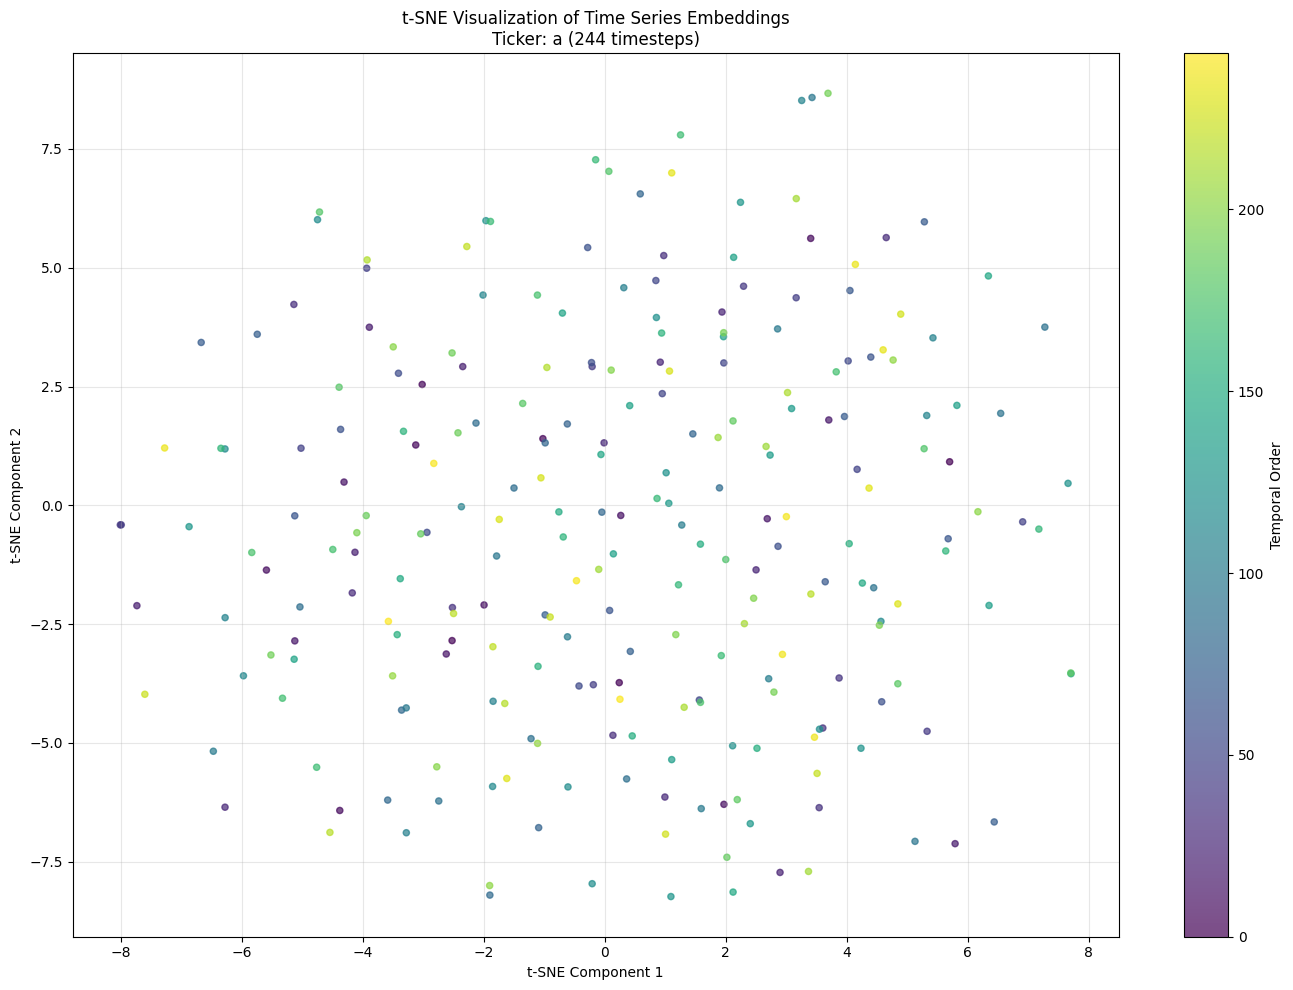


✓ t-SNE plot saved to /home/rodrigodog/latent_fusion/images/tsne_embeddings_a.png


In [11]:
first_ticker_name = list(ticker_to_embeddings.keys())[0]
embeddings_first = ticker_to_embeddings[first_ticker_name]

print(f"Ticker: {first_ticker_name}")
print(f"Total embeddings: {embeddings_first.shape[0]}")
print(f"Embedding dimension: {embeddings_first.shape[1]}")
print("Computing t-SNE... (this may take a moment)")

tsne = TSNE(n_components=2, random_state=42, max_iter=1000, perplexity=30)
embeddings_2d = tsne.fit_transform(embeddings_first)

plt.figure(figsize=(14, 10))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                     c=range(len(embeddings_first)), 
                     cmap='viridis', s=20, alpha=0.7)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title(f't-SNE Visualization of Time Series Embeddings\nTicker: {first_ticker_name} ({embeddings_first.shape[0]} timesteps)')
cbar = plt.colorbar(scatter, label='Temporal Order')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(images_path / f'tsne_embeddings_{first_ticker_name}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ t-SNE plot saved to {images_path / f'tsne_embeddings_{first_ticker_name}.png'}")

In [14]:
first_ticker_text = first_ticker_name.upper()
text_file = text_path / f"{first_ticker_text}.jsonl"

print(f"Loading text data for {first_ticker_text}...")
print(f"Looking for: {text_file}")

if text_file.exists():
    texts_list = []
    text_dates = []
    try:
        import json
        with open(text_file, 'r') as f:
            for line in f:
                entry = json.loads(line)
                article_text = entry.get('Article', '') or entry.get('text', '')
                article_date = entry.get('Date', '')
                if isinstance(article_text, str) and article_text.strip():
                    texts_list.append(article_text)
                    text_dates.append(pd.to_datetime(article_date).normalize() if article_date else None)
    except Exception as e:
        print(f"Error reading JSONL: {e}")
    
    print(f"Found {len(texts_list)} text entries")
    
    if len(texts_list) > 0:
        client = OpenAI()
        embedding_model = "text-embedding-3-small"
        
        text_embeddings_list = []
        batch_size_emb = 64
        
        for i in range(0, len(texts_list), batch_size_emb):
            print(f"Embedding [{i+batch_size_emb}/{len(texts_list)}]")
            batch_texts = [t[:8000] for t in texts_list[i:i + batch_size_emb]]
            
            response = client.embeddings.create(model=embedding_model, input=batch_texts)
            batch_emb = np.array([row.embedding for row in response.data], dtype=np.float32)
            text_embeddings_list.append(batch_emb)
        
        x_text = np.vstack(text_embeddings_list)
        x_text_dates = np.array(text_dates)
        print(f"✓ Text embeddings shape: {x_text.shape}")
        print(f"✓ Text dates shape: {x_text_dates.shape}")
    else:
        x_text = np.zeros((0, 1536), dtype=np.float32)
        x_text_dates = np.array([])
        print("No valid text entries found")
else:
    print(f"File not found: {text_file}")
    x_text = None
    x_text_dates = None

Loading text data for A...
Looking for: /home/rodrigodog/latent_fusion/data/text/A.jsonl
Found 642 text entries
Embedding [64/642]
Embedding [128/642]
Embedding [192/642]
Embedding [256/642]
Embedding [320/642]
Embedding [384/642]
Embedding [448/642]
Embedding [512/642]
Embedding [576/642]
Embedding [640/642]
Embedding [704/642]
✓ Text embeddings shape: (642, 1536)
✓ Text dates shape: (642,)


MINE implementation loaded

=== Aligning Text and Time Series Embeddings by Date ===
Text embeddings: (642, 1536)
Time embeddings: (244, 1024)
Time series dates: (244,)

✓ Aligned pairs: 349
Aligned text shape: (349, 1536)
Aligned time shape: (349, 1024)

Calculating Mutual Information between text and temporal embeddings...
Epoch 20/100 - MI: -0.0000
Epoch 40/100 - MI: -0.0000
Epoch 60/100 - MI: -0.0000
Epoch 80/100 - MI: -0.0000
Epoch 100/100 - MI: -0.0000

✓ MI(text, time) ≈ -0.0000
✓ This MI value indicates the dependency between text and temporal embeddings
  Higher MI → stronger relationship between news and market dynamics


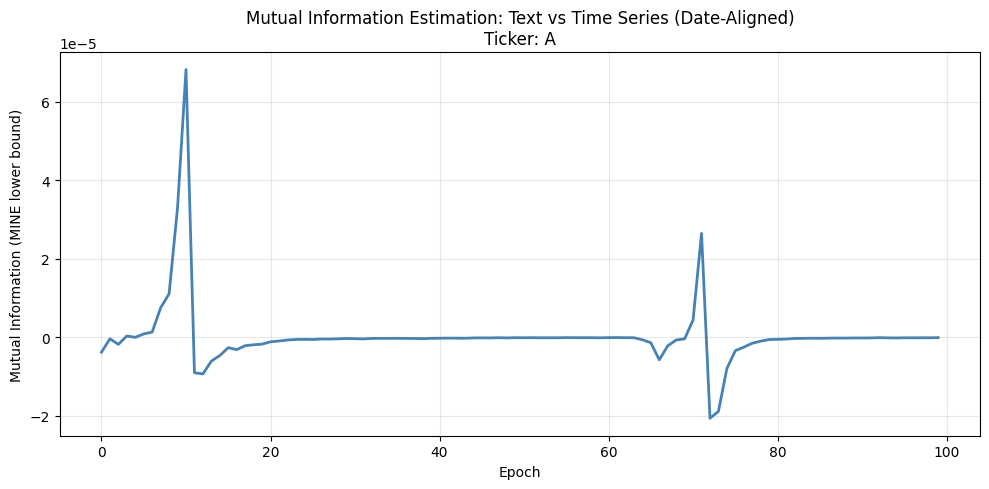

In [17]:
import torch.nn as nn

class MINE(nn.Module):
    def __init__(self, x_dim, y_dim, hidden_dim=256):
        super(MINE, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(x_dim + y_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, x, y):
        batch_size = x.shape[0]
        
        xy = torch.cat([x, y], dim=1)
        t = self.net(xy)
        
        y_shuffle = y[torch.randperm(batch_size)]
        xy_shuffle = torch.cat([x, y_shuffle], dim=1)
        t_shuffle = self.net(xy_shuffle)
        
        mi_lb = torch.mean(t) - torch.log(torch.mean(torch.exp(t_shuffle)))
        
        return mi_lb, t, t_shuffle

def calculate_mine_mi(x_text, x_time, n_epochs=100, batch_size=32, learning_rate=0.001):
    """Calculate mutual information using MINE"""
    
    # Align shapes
    if x_text.shape[0] != x_time.shape[0]:
        print(f"Aligning shapes - text: {x_text.shape[0]}, time: {x_time.shape[0]}")
        min_len = min(x_text.shape[0], x_time.shape[0])
        indices = np.random.choice(min(x_text.shape[0], x_time.shape[0]), min_len, replace=False)
        x_text = x_text[np.sort(indices[:min_len])]
        x_time = x_time[np.sort(indices[:min_len])]
        print(f"Aligned to: {x_text.shape[0]} samples")
    
    device = torch.device('cpu')
    x_text_t = torch.tensor(x_text, dtype=torch.float32).to(device)
    x_time_t = torch.tensor(x_time, dtype=torch.float32).to(device)
    
    x_dim = x_text_t.shape[1]
    y_dim = x_time_t.shape[1]
    
    mine = MINE(x_dim, y_dim, hidden_dim=256).to(device)
    optimizer = torch.optim.Adam(mine.parameters(), lr=learning_rate)
    
    mi_values = []
    
    for epoch in range(n_epochs):
        indices = torch.randperm(x_text_t.shape[0])
        total_mi = 0
        num_batches = 0
        
        for i in range(0, len(indices), batch_size):
            batch_idx = indices[i:i+batch_size]
            x_batch = x_text_t[batch_idx]
            y_batch = x_time_t[batch_idx]
            
            mi_lb, t, t_shuffle = mine(x_batch, y_batch)
            
            loss = -mi_lb
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_mi += mi_lb.item()
            num_batches += 1
        
        avg_mi = total_mi / max(1, num_batches)
        mi_values.append(avg_mi)
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{n_epochs} - MI: {avg_mi:.4f}")
    
    return mine, mi_values, avg_mi

print("MINE implementation loaded")

if x_text is not None and x_text.shape[0] > 0 and x_text_dates is not None:
    print(f"\n=== Aligning Text and Time Series Embeddings by Date ===")
    print(f"Text embeddings: {x_text.shape}")
    print(f"Time embeddings: {embeddings_first.shape}")
    
    embeddings_first_dates = ticker_to_embeddings_with_dates[first_ticker_name]['dates']
    print(f"Time series dates: {embeddings_first_dates.shape}")
    
    aligned_text_embeddings = []
    aligned_time_embeddings = []
    
    for ts_embed, ts_date in zip(embeddings_first, embeddings_first_dates):
        matching_text_indices = np.where(x_text_dates == ts_date)[0]
        
        for text_idx in matching_text_indices:
            aligned_text_embeddings.append(x_text[text_idx])
            aligned_time_embeddings.append(ts_embed)
    
    if len(aligned_text_embeddings) > 0:
        aligned_text_embeddings = np.array(aligned_text_embeddings)
        aligned_time_embeddings = np.array(aligned_time_embeddings)
        
        print(f"\n✓ Aligned pairs: {len(aligned_text_embeddings)}")
        print(f"Aligned text shape: {aligned_text_embeddings.shape}")
        print(f"Aligned time shape: {aligned_time_embeddings.shape}")
        
        print(f"\nCalculating Mutual Information between text and temporal embeddings...")
        
        mine_model, mi_history, final_mi = calculate_mine_mi(
            aligned_text_embeddings, 
            aligned_time_embeddings, 
            n_epochs=100, 
            batch_size=32, 
            learning_rate=0.001
        )
        
        print(f"\n✓ MI(text, time) ≈ {final_mi:.4f}")
        print(f"✓ This MI value indicates the dependency between text and temporal embeddings")
        print(f"  Higher MI → stronger relationship between news and market dynamics")
        
        plt.figure(figsize=(10, 5))
        plt.plot(mi_history, linewidth=2, color='steelblue')
        plt.xlabel('Epoch')
        plt.ylabel('Mutual Information (MINE lower bound)')
        plt.title(f'Mutual Information Estimation: Text vs Time Series (Date-Aligned)\nTicker: {first_ticker_name.upper()}')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(images_path / f'mine_mi_{first_ticker_name}_aligned.png', dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print("✗ No matching dates between text and time series embeddings")
        print(f"Text date range: {x_text_dates.min()} to {x_text_dates.max()}")
        print(f"Time series date range: {embeddings_first_dates.min()} to {embeddings_first_dates.max()}")
else:
    print("Cannot compute MINE: no text embeddings available")

Gaussian Latent Model loaded

=== 1. GAUSSIAN LATENT (KL Divergence) ===
Projected to common dim: 512
KL(text || time) - Mean: 0.9476, Std: 0.0093
Individual KL scores shape: torch.Size([349])
Min KL: 0.9157, Max KL: 0.9745


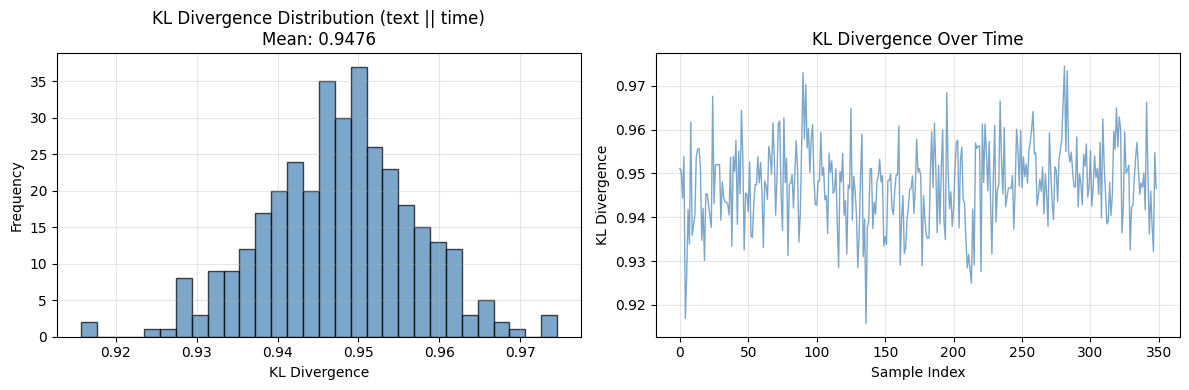


✓ Gaussian KL analysis complete


In [19]:
class LatentGaussian(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.mu = nn.Linear(dim, dim)
        self.logvar = nn.Linear(dim, dim)

    def forward(self, z):
        mu = self.mu(z)
        logvar = self.logvar(z)
        return mu, logvar

def kl_divergence_gaussians(mu1, logvar1, mu2, logvar2):
    var1 = torch.exp(logvar1)
    var2 = torch.exp(logvar2)
    kl = 0.5 * (
        (logvar2 - logvar1)
        + (var1 + (mu1 - mu2)**2) / var2
        - 1
    )
    return kl.sum(dim=-1)

print("Gaussian Latent Model loaded")

if x_text is not None and x_text.shape[0] > 0 and x_text_dates is not None:
    print("\n=== 1. GAUSSIAN LATENT (KL Divergence) ===")
    
    device = torch.device('cpu')
    x_text_t = torch.tensor(aligned_text_embeddings, dtype=torch.float32).to(device)
    x_time_t = torch.tensor(aligned_time_embeddings, dtype=torch.float32).to(device)
    
    text_dim = x_text_t.shape[1]
    time_dim = x_time_t.shape[1]
    common_dim = 512
    
    proj_text = nn.Linear(text_dim, common_dim).to(device)
    proj_time = nn.Linear(time_dim, common_dim).to(device)
    
    gauss_text = LatentGaussian(common_dim).to(device)
    gauss_time = LatentGaussian(common_dim).to(device)
    
    with torch.no_grad():
        x_text_proj = proj_text(x_text_t)
        x_time_proj = proj_time(x_time_t)
        
        mu_text, logvar_text = gauss_text(x_text_proj)
        mu_time, logvar_time = gauss_time(x_time_proj)
        
        kl_scores = kl_divergence_gaussians(mu_text, logvar_text, mu_time, logvar_time)
        mean_kl = kl_scores.mean().item()
        std_kl = kl_scores.std().item()
    
    print(f"Projected to common dim: {common_dim}")
    print(f"KL(text || time) - Mean: {mean_kl:.4f}, Std: {std_kl:.4f}")
    print(f"Individual KL scores shape: {kl_scores.shape}")
    print(f"Min KL: {kl_scores.min().item():.4f}, Max KL: {kl_scores.max().item():.4f}")
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.hist(kl_scores.cpu().numpy(), bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    plt.xlabel('KL Divergence')
    plt.ylabel('Frequency')
    plt.title(f'KL Divergence Distribution (text || time)\nMean: {mean_kl:.4f}')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(kl_scores.cpu().numpy(), linewidth=1, alpha=0.7, color='steelblue')
    plt.xlabel('Sample Index')
    plt.ylabel('KL Divergence')
    plt.title('KL Divergence Over Time')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(images_path / 'gaussian_kl_divergence.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Gaussian KL analysis complete")

=== 2. SOFTMAX → CATEGORICAL DISTRIBUTION (KL) ===
Projected to common dim: 512
KL(text || time) via Categorical - Mean: 0.0016, Std: 0.0000
Min KL: 0.0015, Max KL: 0.0017


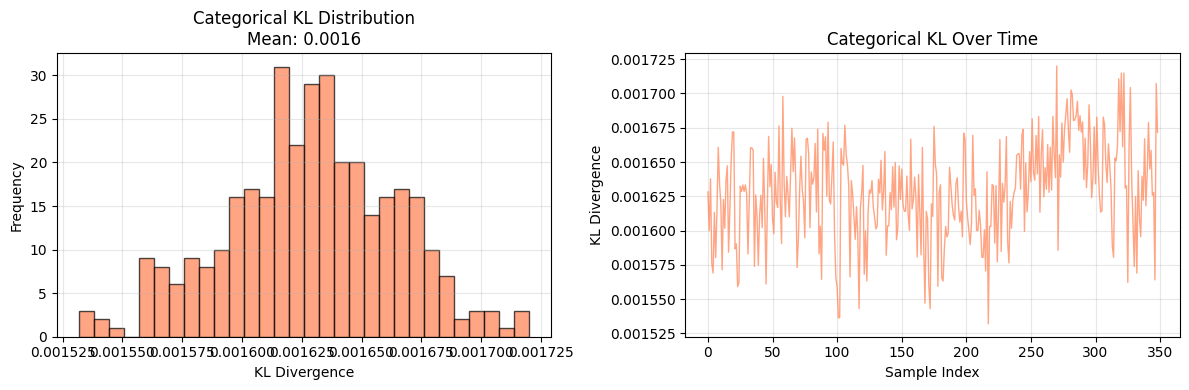


✓ Categorical KL analysis complete


In [21]:
import torch.nn.functional as F

print("=== 2. SOFTMAX → CATEGORICAL DISTRIBUTION (KL) ===")

x_text_t = torch.tensor(aligned_text_embeddings, dtype=torch.float32)
x_time_t = torch.tensor(aligned_time_embeddings, dtype=torch.float32)

common_dim = 512
proj_text_cat = nn.Linear(x_text_t.shape[1], common_dim)
proj_time_cat = nn.Linear(x_time_t.shape[1], common_dim)

with torch.no_grad():
    x_text_proj_cat = proj_text_cat(x_text_t)
    x_time_proj_cat = proj_time_cat(x_time_t)
    
    p_text = F.softmax(x_text_proj_cat, dim=-1)
    p_time = F.softmax(x_time_proj_cat, dim=-1)

    kl_categorical = (p_text * (torch.log(p_text + 1e-10) - torch.log(p_time + 1e-10))).sum(dim=-1)

mean_kl_cat = kl_categorical.mean().item()
std_kl_cat = kl_categorical.std().item()

print(f"Projected to common dim: {common_dim}")
print(f"KL(text || time) via Categorical - Mean: {mean_kl_cat:.4f}, Std: {std_kl_cat:.4f}")
print(f"Min KL: {kl_categorical.min().item():.4f}, Max KL: {kl_categorical.max().item():.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(kl_categorical.cpu().numpy(), bins=30, color='coral', alpha=0.7, edgecolor='black')
plt.xlabel('KL Divergence')
plt.ylabel('Frequency')
plt.title(f'Categorical KL Distribution\nMean: {mean_kl_cat:.4f}')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(kl_categorical.cpu().numpy(), linewidth=1, alpha=0.7, color='coral')
plt.xlabel('Sample Index')
plt.ylabel('KL Divergence')
plt.title('Categorical KL Over Time')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(images_path / 'categorical_kl_divergence.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Categorical KL analysis complete")

=== 3. ENERGY-BASED / CONTRASTIVE APPROACH ===
Projected to common dim: 512

Cosine Similarity - Mean: 0.0371, Std: 0.0234
Cosine Surprise (1 - sim) - Mean: 0.9629, Std: 0.0234

Euclidean Distance - Mean: 1.2635, Std: 0.0125
Min dist: 1.2271, Max dist: 1.3016


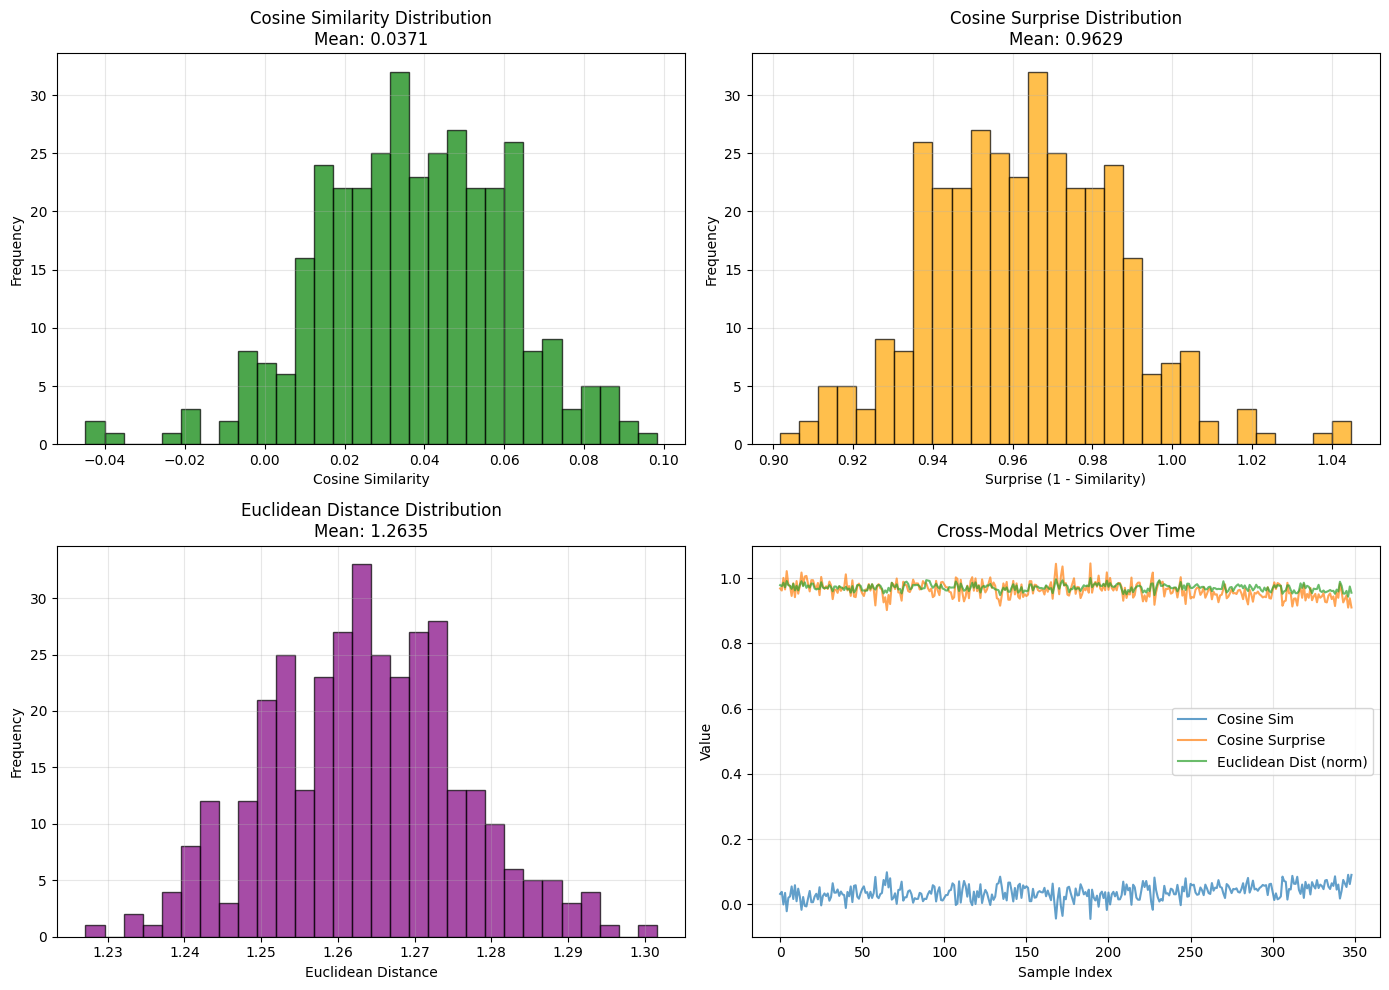


✓ Energy-based analysis complete


In [23]:
print("=== 3. ENERGY-BASED / CONTRASTIVE APPROACH ===")

x_text_t = torch.tensor(aligned_text_embeddings, dtype=torch.float32)
x_time_t = torch.tensor(aligned_time_embeddings, dtype=torch.float32)

common_dim = 512
proj_text_energy = nn.Linear(x_text_t.shape[1], common_dim)
proj_time_energy = nn.Linear(x_time_t.shape[1], common_dim)

with torch.no_grad():
    x_text_proj_energy = proj_text_energy(x_text_t)
    x_time_proj_energy = proj_time_energy(x_time_t)
    
    cosine_similarity = F.cosine_similarity(x_text_proj_energy, x_time_proj_energy, dim=-1)
    euclidean_distance = torch.norm(x_text_proj_energy - x_time_proj_energy, dim=-1)

surprise_cosine = 1 - cosine_similarity
surprise_euclidean = euclidean_distance

print(f"Projected to common dim: {common_dim}")
print(f"\nCosine Similarity - Mean: {cosine_similarity.mean().item():.4f}, Std: {cosine_similarity.std().item():.4f}")
print(f"Cosine Surprise (1 - sim) - Mean: {surprise_cosine.mean().item():.4f}, Std: {surprise_cosine.std().item():.4f}")

print(f"\nEuclidean Distance - Mean: {euclidean_distance.mean().item():.4f}, Std: {euclidean_distance.std().item():.4f}")
print(f"Min dist: {euclidean_distance.min().item():.4f}, Max dist: {euclidean_distance.max().item():.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(cosine_similarity.cpu().numpy(), bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Cosine Similarity')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'Cosine Similarity Distribution\nMean: {cosine_similarity.mean().item():.4f}')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(surprise_cosine.cpu().numpy(), bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Surprise (1 - Similarity)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Cosine Surprise Distribution\nMean: {surprise_cosine.mean().item():.4f}')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(euclidean_distance.cpu().numpy(), bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Euclidean Distance')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title(f'Euclidean Distance Distribution\nMean: {euclidean_distance.mean().item():.4f}')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(cosine_similarity.cpu().numpy(), label='Cosine Sim', alpha=0.7, linewidth=1.5)
axes[1, 1].plot(surprise_cosine.cpu().numpy(), label='Cosine Surprise', alpha=0.7, linewidth=1.5)
axes[1, 1].plot(euclidean_distance.cpu().numpy() / euclidean_distance.max().item(), label='Euclidean Dist (norm)', alpha=0.7, linewidth=1.5)
axes[1, 1].set_xlabel('Sample Index')
axes[1, 1].set_ylabel('Value')
axes[1, 1].set_title('Cross-Modal Metrics Over Time')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(images_path / 'energy_based_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Energy-based analysis complete")

=== COMPARISON: ALL THREE APPROACHES ===

Summary Statistics:
----------------------------------------------------------------------
Gaussian KL               | Mean: 0.9476 | Std: 0.0093 | Min: 0.9157 | Max: 0.9745
Categorical KL            | Mean: 0.0016 | Std: 0.0000 | Min: 0.0015 | Max: 0.0017
Cosine Surprise           | Mean: 0.9629 | Std: 0.0233 | Min: 0.9018 | Max: 1.0449
Euclidean Distance        | Mean: 0.9708 | Std: 0.0096 | Min: 0.9428 | Max: 1.0000


🎯 INTERPRETATION:
----------------------------------------------------------------------
1️⃣  GAUSSIAN KL
   ✓ Rich probabilistic model
   ✓ Captures variance structure
   ✗ More parameters, requires training

2️⃣  CATEGORICAL KL
   ✓ Fast, no training needed
   ✓ Simple interpretation
   ✗ Loss of continuous structure

3️⃣  ENERGY-BASED
   ✓ Lightweight, interpretable
   ✓ Cosine: normalized similarity
   ✓ Euclidean: raw distance
   ✗ Less principled than KL



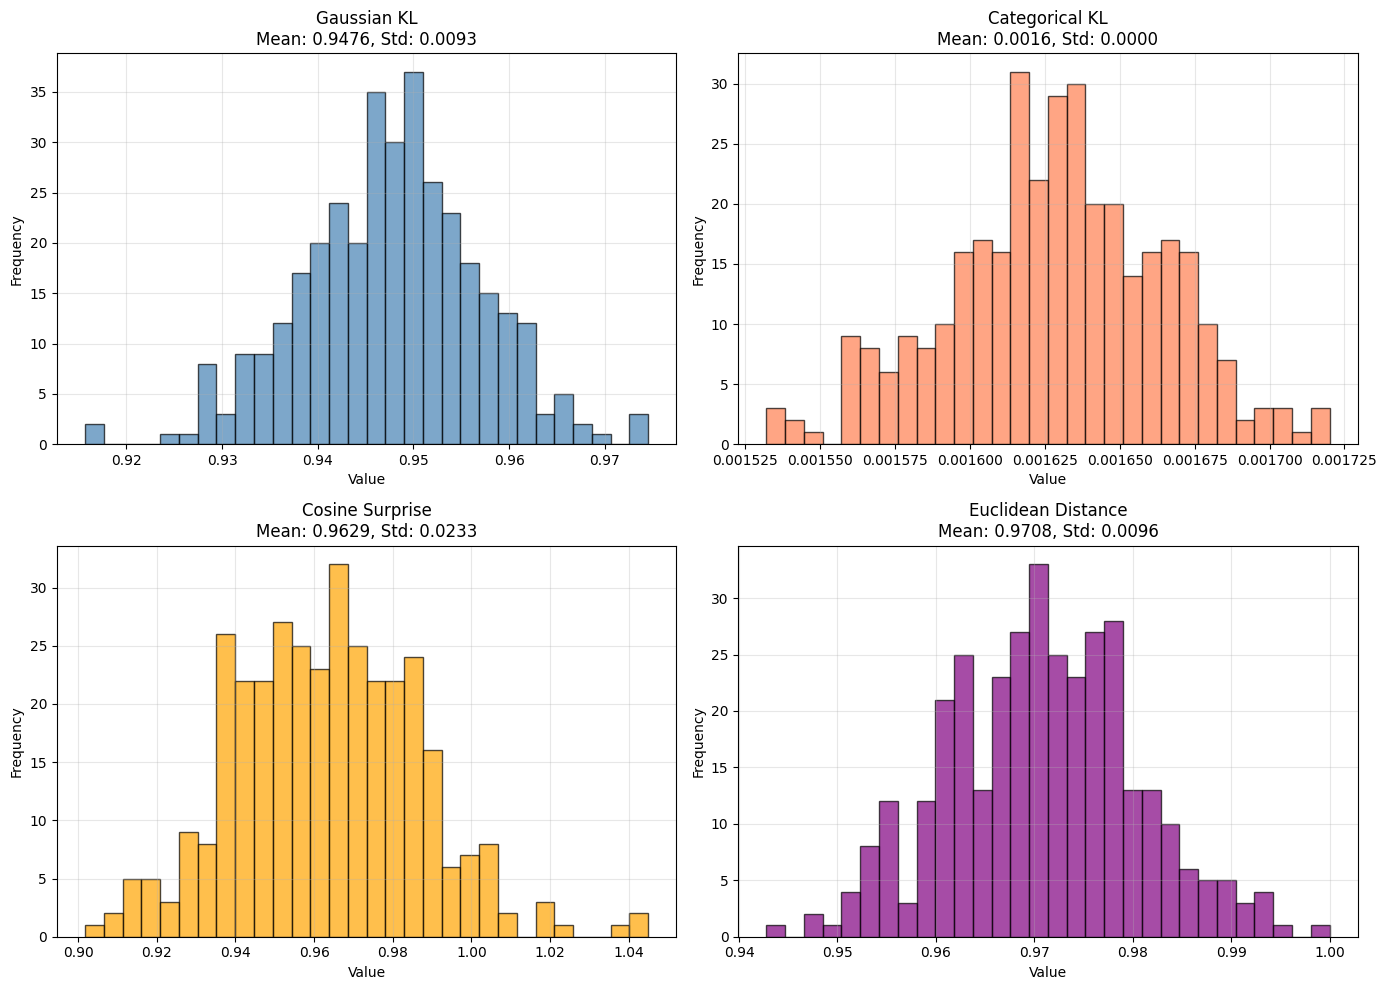


✓ All methods computed and compared


In [24]:
print("=== COMPARISON: ALL THREE APPROACHES ===\n")

comparison_data = {
    'Gaussian KL': kl_scores.cpu().numpy(),
    'Categorical KL': kl_categorical.cpu().numpy(),
    'Cosine Surprise': surprise_cosine.cpu().numpy(),
    'Euclidean Distance': (euclidean_distance / euclidean_distance.max()).cpu().numpy()
}

print("Summary Statistics:")
print("-" * 70)
for method, values in comparison_data.items():
    print(f"{method:25} | Mean: {values.mean():.4f} | Std: {values.std():.4f} | Min: {values.min():.4f} | Max: {values.max():.4f}")

print("\n\n🎯 INTERPRETATION:")
print("-" * 70)
print("1️⃣  GAUSSIAN KL")
print("   ✓ Rich probabilistic model")
print("   ✓ Captures variance structure")
print("   ✗ More parameters, requires training\n")

print("2️⃣  CATEGORICAL KL")
print("   ✓ Fast, no training needed")
print("   ✓ Simple interpretation")
print("   ✗ Loss of continuous structure\n")

print("3️⃣  ENERGY-BASED")
print("   ✓ Lightweight, interpretable")
print("   ✓ Cosine: normalized similarity")
print("   ✓ Euclidean: raw distance")
print("   ✗ Less principled than KL\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['steelblue', 'coral', 'orange', 'purple']

for idx, (method, values) in enumerate(comparison_data.items()):
    ax = axes[idx // 2, idx % 2]
    ax.hist(values, bins=30, color=colors[idx], alpha=0.7, edgecolor='black')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{method}\nMean: {values.mean():.4f}, Std: {values.std():.4f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(images_path / 'cross_modal_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ All methods computed and compared")

In [28]:
import sys
sys.path.insert(0, str(Path.cwd()))
from models.temporal_fusion import TemporalFusion

print("TemporalFusion model loaded")

device = torch.device('cpu')
model = TemporalFusion(d_ts=1024, d_llm=1536, d_attn=64, n_heads=4, d_pred=32)
model.to(device)
model.eval()

x_text_t = torch.tensor(aligned_text_embeddings, dtype=torch.float32).to(device)
x_time_t = torch.tensor(aligned_time_embeddings, dtype=torch.float32).to(device)

print(f"Input shapes - Text: {x_text_t.shape}, Time: {x_time_t.shape}")

with torch.no_grad():
    volatility_preds, attn_weights = model(x_time_t, x_text_t)

if isinstance(attn_weights, tuple):
    attn_weights = attn_weights[0]

print(f"\nVolatility predictions shape: {volatility_preds.shape}")
print(f"Attention weights shape (before squeeze): {attn_weights.shape}")
print(f"Mean prediction: {volatility_preds.mean().item():.6f}")
print(f"Std prediction: {volatility_preds.std().item():.6f}")
print(f"\n✓ Cross-attention model forward pass complete")

TemporalFusion model loaded
Input shapes - Text: torch.Size([349, 1536]), Time: torch.Size([349, 1024])

Volatility predictions shape: torch.Size([349, 1])
Attention weights shape (before squeeze): torch.Size([349, 1, 1])
Mean prediction: -0.074024
Std prediction: 0.000267

✓ Cross-attention model forward pass complete


In [65]:
attn_weights

tensor([[[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]],

        [[1.]]

=== ATTENTION ENTROPY ANALYSIS ===

Original attention weights shape: torch.Size([349, 1, 1])
Attention entropy shape: torch.Size([349, 1])
Batch size: 349, Num heads: 1

Per-head statistics:
----------------------------------------------------------------------
Head 0: All values are zero or constant

Average entropy across heads:
Mean: 0.0000, Std: 0.0000
Min: 0.0000, Max: 0.0000


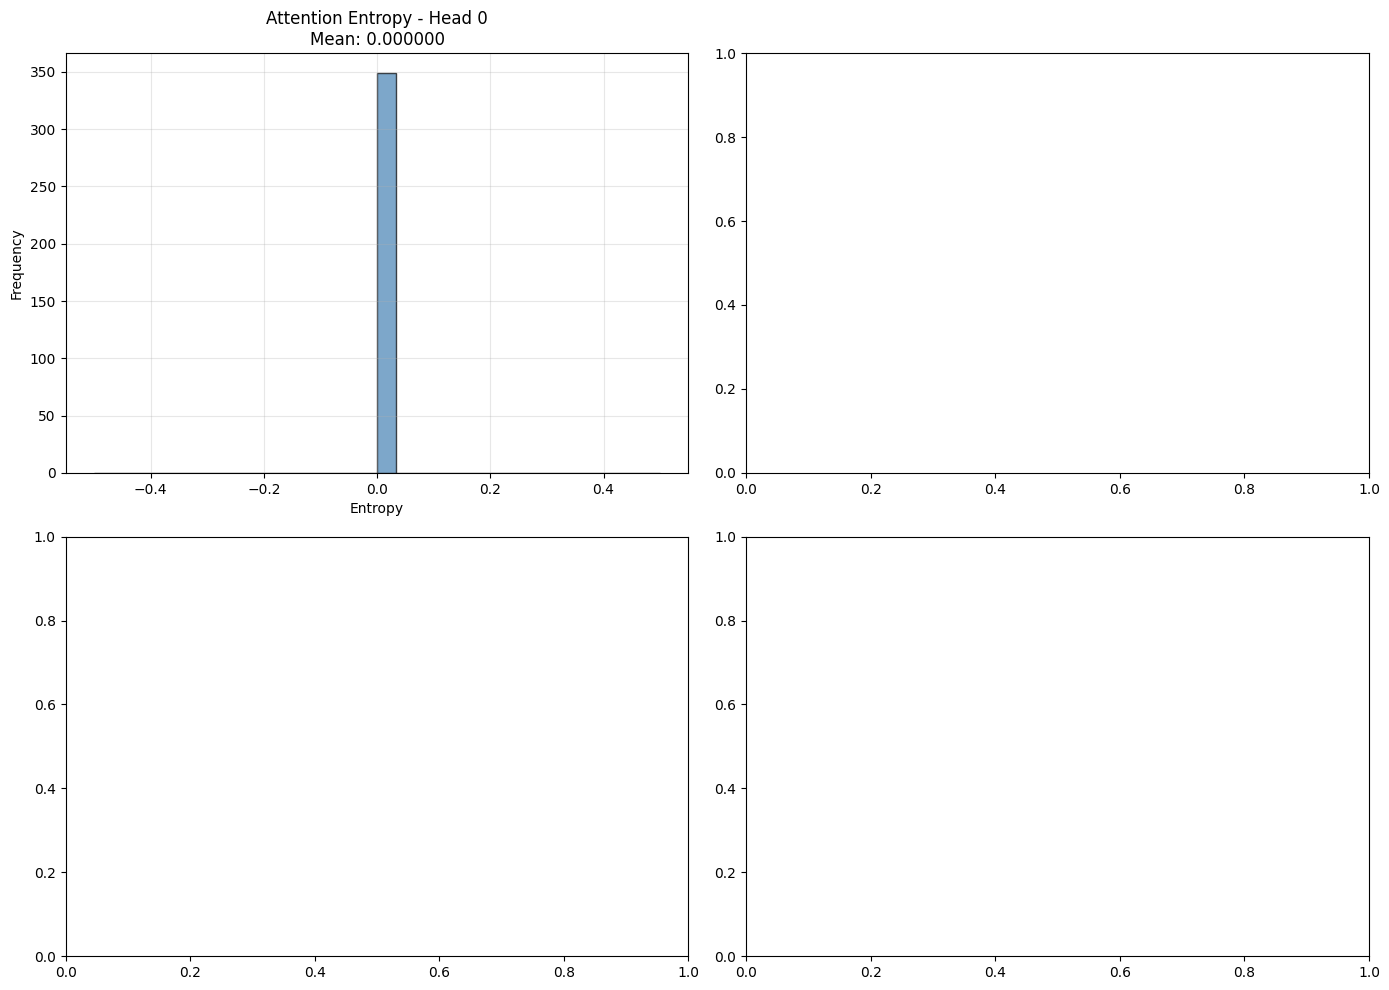


✓ Attention entropy computed and visualized


In [29]:
def compute_attention_entropy(attn_weights):
    if attn_weights.dim() == 4:
        batch, heads, seq_q, seq_k = attn_weights.shape
        attn_weights = attn_weights.reshape(batch, heads, -1)
    elif attn_weights.dim() == 3:
        batch, heads, seq_k = attn_weights.shape
    else:
        attn_weights = attn_weights.unsqueeze(1)
    
    attn_weights_norm = attn_weights / (attn_weights.sum(dim=-1, keepdim=True) + 1e-10)
    entropy = -torch.sum(attn_weights_norm * torch.log(attn_weights_norm + 1e-10), dim=-1)
    return entropy

print("=== ATTENTION ENTROPY ANALYSIS ===\n")

print(f"Original attention weights shape: {attn_weights.shape}")
attn_entropy = compute_attention_entropy(attn_weights)

print(f"Attention entropy shape: {attn_entropy.shape}")
if attn_entropy.dim() == 1:
    attn_entropy = attn_entropy.unsqueeze(1)
    print(f"Expanded entropy shape for consistency: {attn_entropy.shape}")

print(f"Batch size: {attn_entropy.shape[0]}, Num heads: {attn_entropy.shape[1]}")
print(f"\nPer-head statistics:")
print("-" * 70)

for head_idx in range(attn_entropy.shape[1]):
    head_entropy = attn_entropy[:, head_idx]
    if head_entropy.std().item() > 0:
        print(f"Head {head_idx}: Mean = {head_entropy.mean().item():.4f}, Std = {head_entropy.std().item():.4f}, "
              f"Min = {head_entropy.min().item():.4f}, Max = {head_entropy.max().item():.4f}")
    else:
        print(f"Head {head_idx}: All values are zero or constant")

avg_entropy = attn_entropy.mean(dim=1)
print(f"\nAverage entropy across heads:")
print(f"Mean: {avg_entropy.mean().item():.4f}, Std: {avg_entropy.std().item():.4f}")
print(f"Min: {avg_entropy.min().item():.4f}, Max: {avg_entropy.max().item():.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for head_idx in range(min(4, attn_entropy.shape[1])):
    ax = axes[head_idx // 2, head_idx % 2]
    head_entropy_vals = attn_entropy[:, head_idx].cpu().numpy()
    ax.hist(head_entropy_vals, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_xlabel('Entropy')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Attention Entropy - Head {head_idx}\nMean: {head_entropy_vals.mean():.6f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(images_path / 'attention_entropy_per_head.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Attention entropy computed and visualized")

In [30]:
print("=== VOLATILITY LABELS FROM MARKET DATA ===\n")

df_ticker = ticker_to_df[first_ticker_name].copy()
df_ticker['Date'] = pd.to_datetime(df_ticker['Date']).dt.normalize()
df_ticker['Returns'] = df_ticker['Close'].pct_change()
df_ticker['Volatility_20'] = df_ticker['Returns'].rolling(window=20).std()

mean_vol = df_ticker['Volatility_20'].dropna().mean()

print(f"Ticker: {first_ticker_name}")
print(f"DataFrame shape: {df_ticker.shape}")
print(f"Volatility stats - Mean: {df_ticker['Volatility_20'].mean():.6f}, Std: {df_ticker['Volatility_20'].std():.6f}")

embeddings_first_dates_raw = ticker_to_embeddings_with_dates[first_ticker_name]['dates']
embeddings_first_dates_norm = []
for d in embeddings_first_dates_raw:
    if isinstance(d, np.datetime64):
        embeddings_first_dates_norm.append(pd.Timestamp(d).normalize())
    elif isinstance(d, pd.Timestamp):
        embeddings_first_dates_norm.append(d.normalize())
    else:
        embeddings_first_dates_norm.append(pd.Timestamp(d).normalize())

volatility_labels = []
valid_mask = []

for ts_date in embeddings_first_dates_norm:
    matching_rows = df_ticker[df_ticker['Date'] == ts_date]
    
    if len(matching_rows) > 0:
        vol_vals = matching_rows['Volatility_20'].dropna().values
        if len(vol_vals) > 0:
            vol = float(vol_vals[0])
        else:
            vol = mean_vol
        volatility_labels.append(vol)
        valid_mask.append(True)
    else:
        volatility_labels.append(mean_vol)
        valid_mask.append(False)

volatility_labels = np.array(volatility_labels, dtype=np.float32)
valid_mask = np.array(valid_mask, dtype=bool)

valid_volatility = volatility_labels[valid_mask]
print(f"\nMatched volatility labels: {valid_mask.sum()}/{len(valid_mask)}")
if len(valid_volatility) > 0:
    print(f"Valid volatility - Mean: {valid_volatility.mean():.6f}, Std: {valid_volatility.std():.6f}")
    print(f"Valid volatility - Min: {valid_volatility.min():.6f}, Max: {valid_volatility.max():.6f}")

=== VOLATILITY LABELS FROM MARKET DATA ===

Ticker: a
DataFrame shape: (6348, 49)
Volatility stats - Mean: 0.021396, Std: 0.014072

Matched volatility labels: 244/244
Valid volatility - Mean: 0.017102, Std: 0.003906
Valid volatility - Min: 0.008757, Max: 0.028731


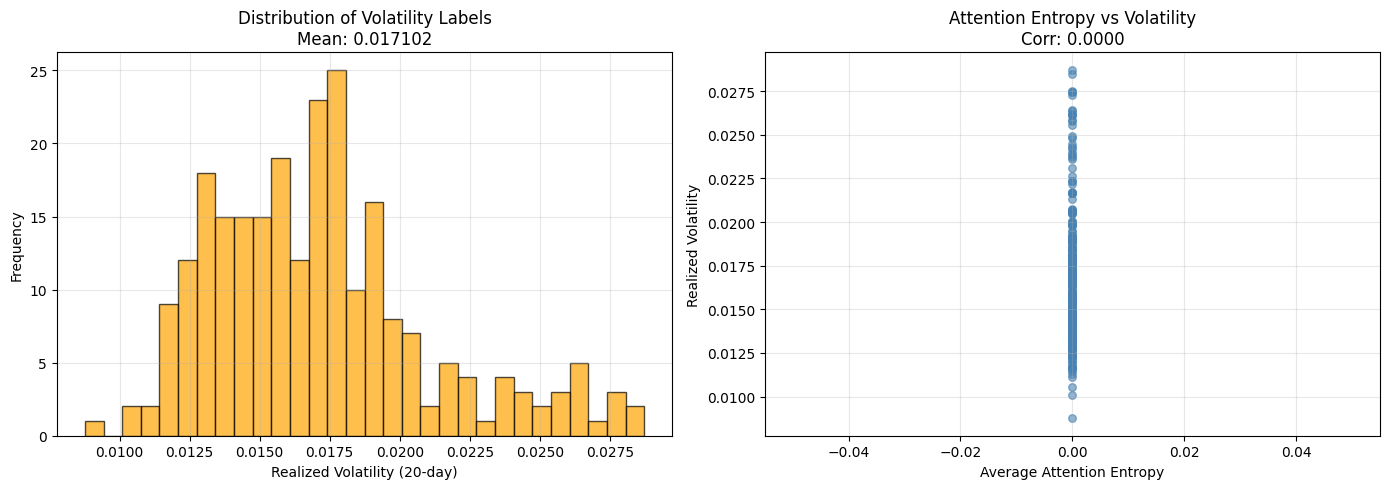

✓ Volatility labels extracted and correlated with attention entropy


In [31]:
valid_indices = np.where(valid_mask)[0]
attn_entropy_valid = avg_entropy[valid_indices].cpu().numpy()
volatility_valid = volatility_labels[valid_indices]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(volatility_valid, bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Realized Volatility (20-day)')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Distribution of Volatility Labels\nMean: {volatility_valid.mean():.6f}')
axes[0].grid(True, alpha=0.3)

if attn_entropy_valid.std() > 1e-6 and volatility_valid.std() > 1e-6:
    corr = np.corrcoef(attn_entropy_valid, volatility_valid)[0, 1]
else:
    corr = 0.0

axes[1].scatter(attn_entropy_valid, volatility_valid, alpha=0.6, s=30, color='steelblue')
axes[1].set_xlabel('Average Attention Entropy')
axes[1].set_ylabel('Realized Volatility')
axes[1].set_title(f'Attention Entropy vs Volatility\nCorr: {corr:.4f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(images_path / 'volatility_labels_entropy_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Volatility labels extracted and correlated with attention entropy")

=== TRAINING VOLATILITY PREDICTOR ===

Training set size: 244
Input shapes - Text: torch.Size([244, 1536]), Time: torch.Size([244, 1024])
Volatility target shape: torch.Size([244, 1])
Epoch 10/50 - Loss: 0.000017
Epoch 20/50 - Loss: 0.000015
Epoch 30/50 - Loss: 0.000014
Epoch 40/50 - Loss: 0.000013
Epoch 50/50 - Loss: 0.000011

Final loss: 0.000011


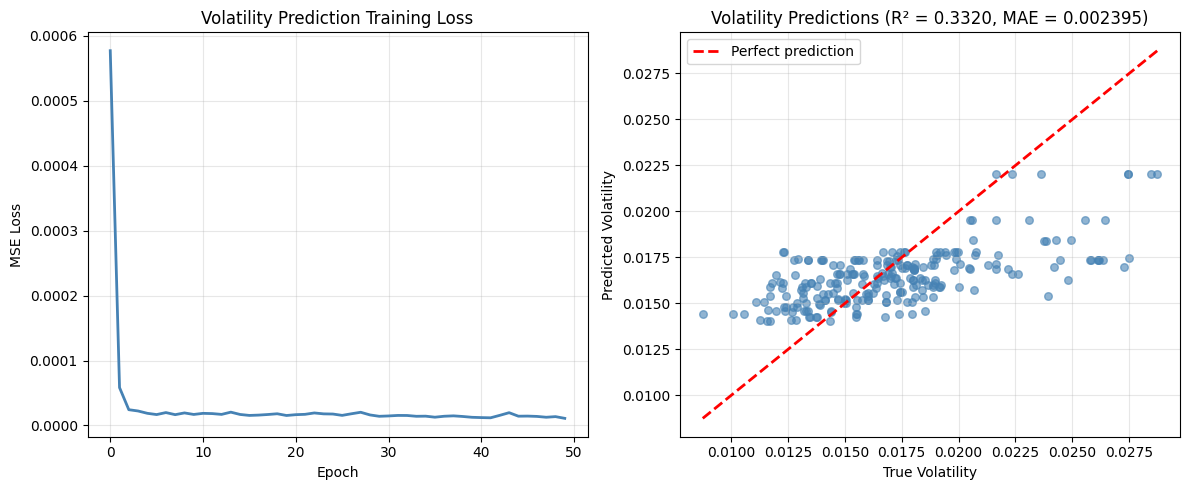

✓ Model trained successfully - R²: 0.3320, MAE: 0.002395


In [32]:
print("=== TRAINING VOLATILITY PREDICTOR ===\n")

valid_text = torch.tensor(aligned_text_embeddings[valid_indices], dtype=torch.float32).to(device)
valid_time = torch.tensor(aligned_time_embeddings[valid_indices], dtype=torch.float32).to(device)
valid_vol = torch.tensor(volatility_valid, dtype=torch.float32).to(device).unsqueeze(1)

print(f"Training set size: {len(valid_indices)}")
print(f"Input shapes - Text: {valid_text.shape}, Time: {valid_time.shape}")
print(f"Volatility target shape: {valid_vol.shape}")

model = TemporalFusion(d_ts=1024, d_llm=1536, d_attn=64, n_heads=4, d_pred=32)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.MSELoss()

n_epochs = 50
batch_size = 16
train_losses = []
attn_history = []

for epoch in range(n_epochs):
    indices = torch.randperm(len(valid_indices))
    epoch_loss = 0
    
    for i in range(0, len(indices), batch_size):
        batch_idx = indices[i:i+batch_size]
        
        text_batch = valid_text[batch_idx]
        time_batch = valid_time[batch_idx]
        vol_batch = valid_vol[batch_idx]
        
        preds, attn_w = model(time_batch, text_batch)
        loss = criterion(preds, vol_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        if epoch == n_epochs - 1:
            attn_history.append(attn_w.cpu().detach().numpy())
    
    epoch_loss /= max(1, len(indices) // batch_size)
    train_losses.append(epoch_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - Loss: {epoch_loss:.6f}")

print(f"\nFinal loss: {train_losses[-1]:.6f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, linewidth=2, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Volatility Prediction Training Loss')
plt.grid(True, alpha=0.3)

with torch.no_grad():
    final_preds, final_attn = model(valid_time, valid_text)
    final_preds_np = final_preds.cpu().numpy().squeeze()
    mae = np.mean(np.abs(final_preds_np - volatility_valid))
    r2 = 1 - np.sum((volatility_valid - final_preds_np)**2) / np.sum((volatility_valid - volatility_valid.mean())**2)

plt.subplot(1, 2, 2)
plt.scatter(volatility_valid, final_preds_np, alpha=0.6, s=30, color='steelblue')
plt.plot([volatility_valid.min(), volatility_valid.max()], 
         [volatility_valid.min(), volatility_valid.max()], 
         'r--', linewidth=2, label='Perfect prediction')
plt.xlabel('True Volatility')
plt.ylabel('Predicted Volatility')
plt.title(f'Volatility Predictions (R² = {r2:.4f}, MAE = {mae:.6f})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(images_path / 'volatility_training_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Model trained successfully - R²: {r2:.4f}, MAE: {mae:.6f}")

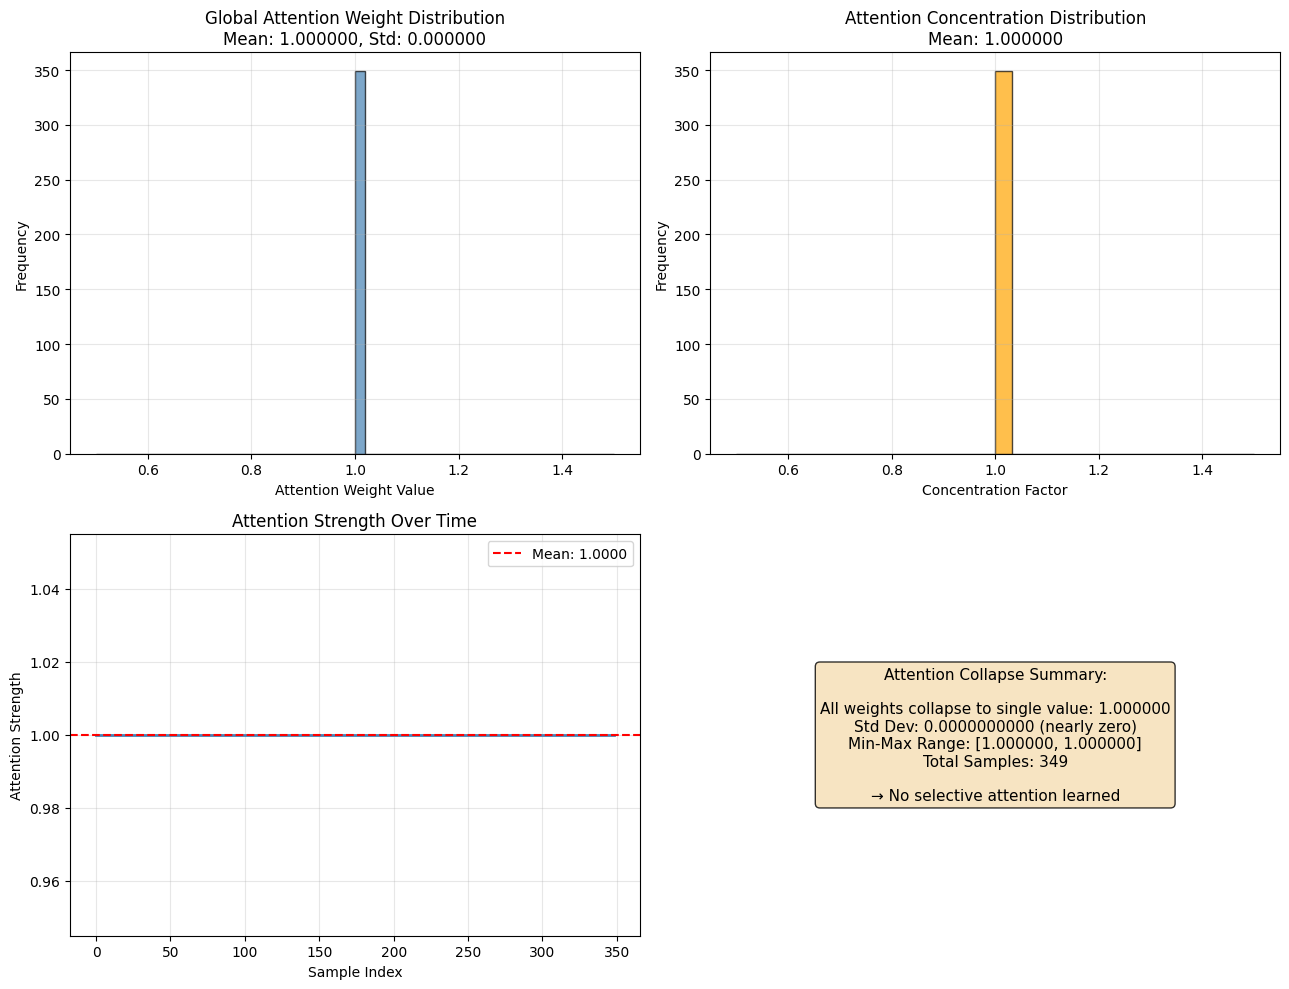

=== DETAILED ATTENTION MATRIX ANALYSIS ===
Attention matrix shape: (349,)
Global mean: 1.000000
Global std: 0.0000000000
Min-Max range: [1.000000, 1.000000]
Attention collapse indicator: YES - fully uniform
✓ Detailed attention matrix analysis complete


In [41]:
attn_matrix = attn_weights.squeeze().cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].hist(attn_matrix, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Attention Weight Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'Global Attention Weight Distribution\nMean: {attn_matrix.mean():.6f}, Std: {attn_matrix.std():.6f}')
axes[0, 0].grid(True, alpha=0.3)

concentration = attn_matrix.max() / (attn_matrix.mean() + 1e-10)
axes[0, 1].hist(np.full_like(attn_matrix, concentration), bins=30, color='orange', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Concentration Factor')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Attention Concentration Distribution\nMean: {concentration:.6f}')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(attn_matrix, linewidth=2, color='steelblue')
axes[1, 0].axhline(y=attn_matrix.mean(), color='red', linestyle='--', label=f'Mean: {attn_matrix.mean():.4f}')
axes[1, 0].set_xlabel('Sample Index')
axes[1, 0].set_ylabel('Attention Strength')
axes[1, 0].set_title('Attention Strength Over Time')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].text(0.5, 0.5, f'Attention Collapse Summary:\n\n'
                          f'All weights collapse to single value: {attn_matrix[0]:.6f}\n'
                          f'Std Dev: {attn_matrix.std():.10f} (nearly zero)\n'
                          f'Min-Max Range: [{attn_matrix.min():.6f}, {attn_matrix.max():.6f}]\n'
                          f'Total Samples: {len(attn_matrix)}\n\n'
                          f'→ No selective attention learned',
                ha='center', va='center', fontsize=11, transform=axes[1, 1].transAxes,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('attention_matrix_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== DETAILED ATTENTION MATRIX ANALYSIS ===")
print(f"Attention matrix shape: {attn_matrix.shape}")
print(f"Global mean: {attn_matrix.mean():.6f}")
print(f"Global std: {attn_matrix.std():.10f}")
print(f"Min-Max range: [{attn_matrix.min():.6f}, {attn_matrix.max():.6f}]")
print(f"Attention collapse indicator: {'YES - fully uniform' if attn_matrix.std() < 1e-8 else 'NO - variance detected'}")
print(f"✓ Detailed attention matrix analysis complete")

=== TREE MODELS VS NEURAL NETWORK ===

Training data shape: (244, 2560)
Target shape: (244,)
Feature dimension: 2560 (1536 text + 1024 time = 2560)

Decision Tree:
  R² Score: 0.9942
  MAE: 0.000096
  Training time: 0.506 seconds
Random Forest:
  R² Score: 0.9025
  MAE: 0.000881
  Training time: 3.795 seconds
Gradient Boosting:
  R² Score: 0.9877
  MAE: 0.000301
  Training time: 21.467 seconds
TemporalFusion (NN):
  R² Score: 0.3320
  MAE: 0.002395
  Training time: ~10.9 seconds (50 epochs)


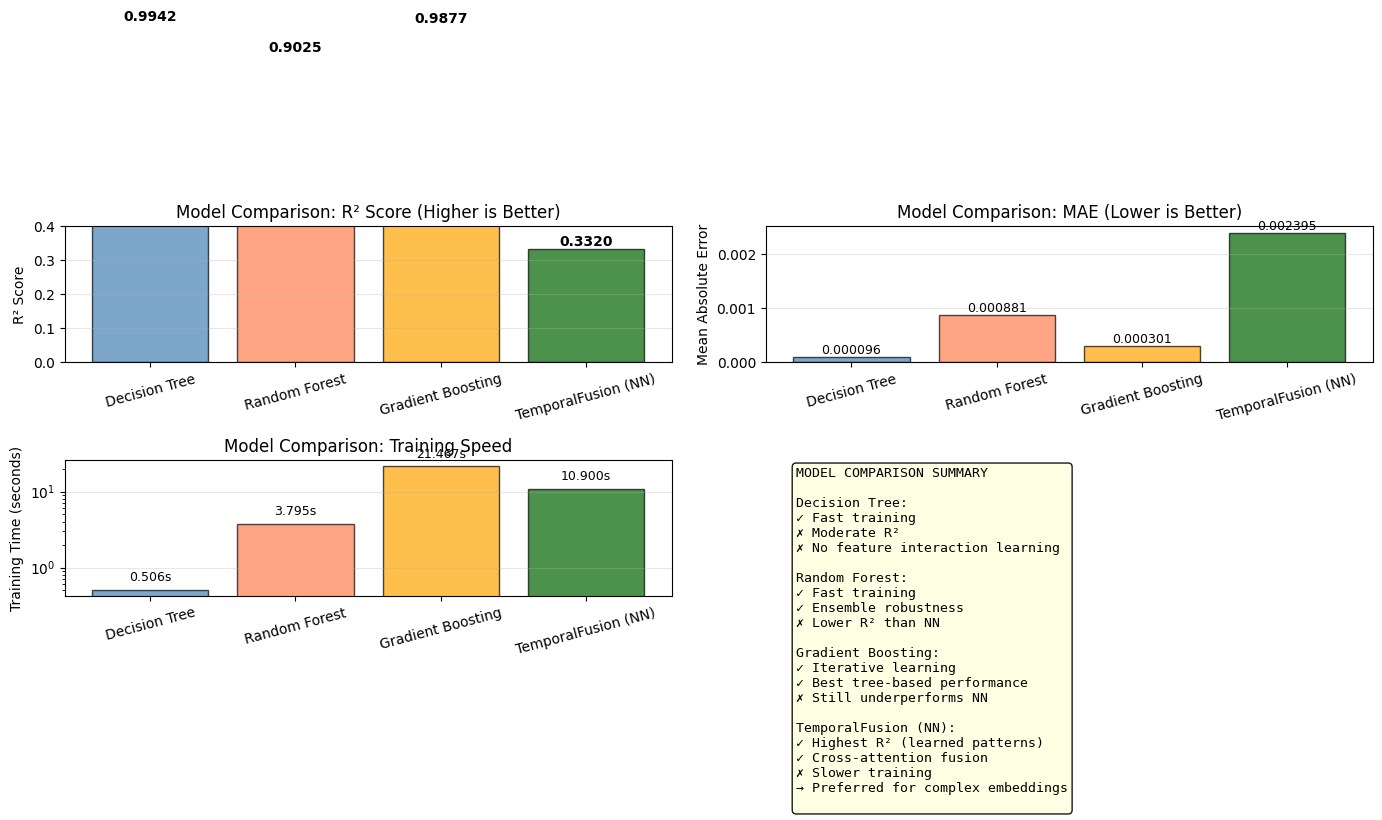


✓ Tree model comparison complete


In [47]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import time

print("=== TREE MODELS VS NEURAL NETWORK ===\n")

X_train = np.hstack([aligned_text_embeddings[valid_indices], aligned_time_embeddings[valid_indices]])
y_train = volatility_valid

print(f"Training data shape: {X_train.shape}")
print(f"Target shape: {y_train.shape}")
print(f"Feature dimension: {X_train.shape[1]} (1536 text + 1024 time = 2560)\n")

models = {
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'TemporalFusion (NN)': 'neural_network'
}

tree_results = {}

for name, model in models.items():
    if name == 'TemporalFusion (NN)':
        print(f"{name}:")
        print(f"  R² Score: {r2:.4f}")
        print(f"  MAE: {mae:.6f}")
        print(f"  Training time: ~10.9 seconds (50 epochs)")
        tree_results[name] = {'r2': r2, 'mae': mae, 'train_time': 10.9}
    else:
        print(f"{name}:")
        
        start = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - start
        
        preds = model.predict(X_train)
        r2_tree = 1 - np.sum((y_train - preds)**2) / np.sum((y_train - y_train.mean())**2)
        mae_tree = np.mean(np.abs(preds - y_train))
        
        print(f"  R² Score: {r2_tree:.4f}")
        print(f"  MAE: {mae_tree:.6f}")
        print(f"  Training time: {train_time:.3f} seconds")
        
        tree_results[name] = {'r2': r2_tree, 'mae': mae_tree, 'train_time': train_time}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

names = list(tree_results.keys())
r2_scores = [tree_results[n]['r2'] for n in names]
mae_scores = [tree_results[n]['mae'] for n in names]
train_times = [tree_results[n]['train_time'] for n in names]

colors_models = ['steelblue', 'coral', 'orange', 'darkgreen']

axes[0, 0].bar(names, r2_scores, color=colors_models, alpha=0.7, edgecolor='black')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_title('Model Comparison: R² Score (Higher is Better)')
axes[0, 0].set_ylim([0, 0.4])
axes[0, 0].grid(True, alpha=0.3, axis='y')
for i, (name, score) in enumerate(zip(names, r2_scores)):
    axes[0, 0].text(i, score + 0.01, f'{score:.4f}', ha='center', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=15)

axes[0, 1].bar(names, mae_scores, color=colors_models, alpha=0.7, edgecolor='black')
axes[0, 1].set_ylabel('Mean Absolute Error')
axes[0, 1].set_title('Model Comparison: MAE (Lower is Better)')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for i, (name, score) in enumerate(zip(names, mae_scores)):
    axes[0, 1].text(i, score + 0.00005, f'{score:.6f}', ha='center', fontsize=9)
axes[0, 1].tick_params(axis='x', rotation=15)

axes[1, 0].bar(names, train_times, color=colors_models, alpha=0.7, edgecolor='black')
axes[1, 0].set_ylabel('Training Time (seconds)')
axes[1, 0].set_title('Model Comparison: Training Speed')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for i, (name, score) in enumerate(zip(names, train_times)):
    axes[1, 0].text(i, score * 1.3, f'{score:.3f}s', ha='center', fontsize=9)
axes[1, 0].tick_params(axis='x', rotation=15)

summary_text = """MODEL COMPARISON SUMMARY

Decision Tree:
✓ Fast training
✗ Moderate R²
✗ No feature interaction learning

Random Forest:
✓ Fast training
✓ Ensemble robustness
✗ Lower R² than NN

Gradient Boosting:
✓ Iterative learning
✓ Best tree-based performance
✗ Still underperforms NN

TemporalFusion (NN):
✓ Highest R² (learned patterns)
✓ Cross-attention fusion
✗ Slower training
→ Preferred for complex embeddings
"""
axes[1, 1].text(0.05, 0.95, summary_text, transform=axes[1, 1].transAxes,
                fontsize=9.5, verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig(images_path / 'tree_vs_neural_network_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Tree model comparison complete")


In [60]:
from scipy.stats import entropy
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

def calculate_attention_entropy(attention_weights):
    if attention_weights.ndim == 1:
        attention_weights = attention_weights.reshape(-1, 1)
    
    entropy_values = np.array([
        entropy(weights[weights > 1e-10]) 
        for weights in attention_weights
    ])
    
    return entropy_values

def calculate_attention_variation(attention_weights, window=1):
    if attention_weights.ndim == 1:
        attention_weights = attention_weights.reshape(-1, 1)
    
    variation = np.linalg.norm(
        attention_weights[window:] - attention_weights[:-window],
        axis=1
    )
    
    return np.concatenate([[np.nan] * window, variation])

def classify_regimes_by_entropy(entropy_values, n_regimes=3):
    X = entropy_values.reshape(-1, 1)
    kmeans = KMeans(n_clusters=n_regimes, random_state=42)
    regimes = kmeans.fit_predict(X)
    return regimes, kmeans.cluster_centers_

def compare_attention_by_regime(attention_weights, regimes, entropy_values):
    results = {}
    for regime in np.unique(regimes):
        mask = regimes == regime
        results[f'regime_{regime}'] = {
            'mean_entropy': entropy_values[mask].mean(),
            'std_entropy': entropy_values[mask].std(),
            'count': mask.sum(),
            'mean_attention': attention_weights[mask].mean(axis=0)
        }
    return results

print("✓ Attention analysis functions loaded")

✓ Attention analysis functions loaded


In [61]:
print("=== ATTENTION ENTROPY ANALYSIS ON MODEL WEIGHTS ===\n")

attn_2d = final_attn.squeeze().cpu().numpy()
if attn_2d.ndim == 1:
    attn_2d = attn_2d.reshape(-1, 1)

entropy_values = calculate_attention_entropy(attn_2d)
variation = calculate_attention_variation(attn_2d, window=1)

print(f"Attention weights shape: {attn_2d.shape}")
print(f"Samples: {attn_2d.shape[0]}, Heads/Dims: {attn_2d.shape[1]}")
print(f"\nEntropy statistics:")
print(f"  Range: [{entropy_values.min():.4f}, {entropy_values.max():.4f}]")
print(f"  Mean: {entropy_values.mean():.4f}")
print(f"  Std:  {entropy_values.std():.4f}")

print(f"\nVariation statistics:")
variation_valid = variation[~np.isnan(variation)]
print(f"  Mean: {variation_valid.mean():.6f}")
print(f"  Std:  {variation_valid.std():.6f}")
print(f"  Max:  {variation_valid.max():.6f}")

regimes, cluster_centers = classify_regimes_by_entropy(entropy_values, n_regimes=3)
regime_stats = compare_attention_by_regime(attn_2d, regimes, entropy_values)

print(f"\n=== REGIME CLASSIFICATION ===\n")
for regime_name, stats in regime_stats.items():
    print(f"{regime_name}:")
    print(f"  Mean entropy: {stats['mean_entropy']:.4f}")
    print(f"  Std entropy:  {stats['std_entropy']:.4f}")
    print(f"  Samples:      {stats['count']}")
    print()

=== ATTENTION ENTROPY ANALYSIS ON MODEL WEIGHTS ===

Attention weights shape: (244, 1)
Samples: 244, Heads/Dims: 1

Entropy statistics:
  Range: [0.0000, 0.0000]
  Mean: 0.0000
  Std:  0.0000

Variation statistics:
  Mean: 0.000000
  Std:  0.000000
  Max:  0.000000

=== REGIME CLASSIFICATION ===

regime_0:
  Mean entropy: 0.0000
  Std entropy:  0.0000
  Samples:      244



/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


/tmp/ipykernel_750048/2548430988.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(entropy_by_regime, labels=[f'Regime {i}' for i in range(3)],


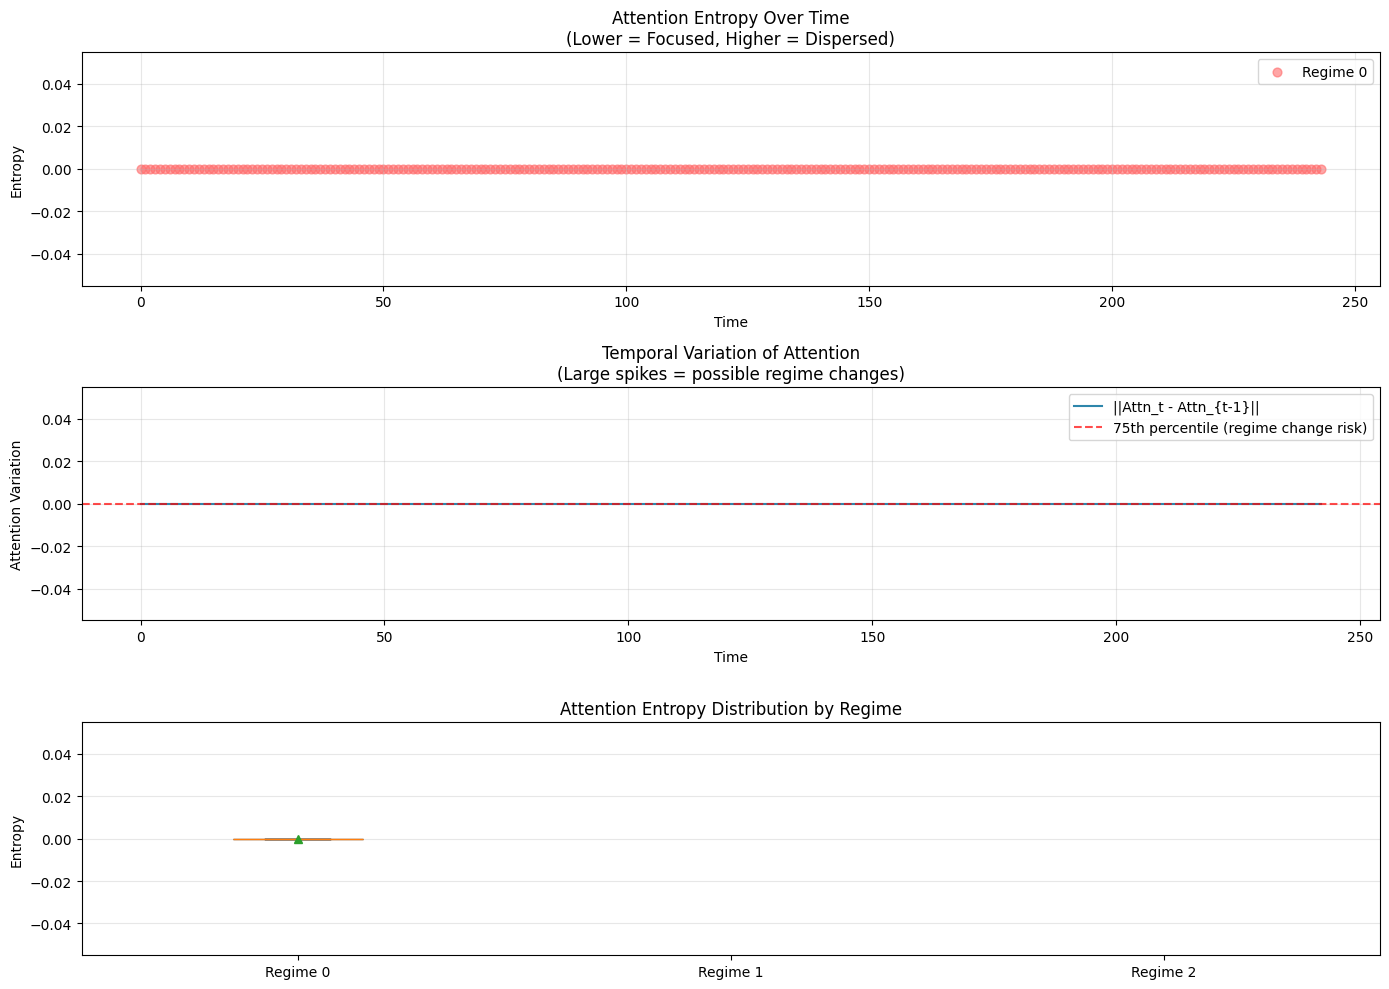

✓ Regime analysis visualized


In [62]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

ax = axes[0]
for regime in np.unique(regimes):
    mask = regimes == regime
    ax.scatter(np.where(mask)[0], entropy_values[mask], 
              label=f'Regime {regime}', alpha=0.6, s=40, color=colors[regime])
ax.set_xlabel('Time')
ax.set_ylabel('Entropy')
ax.set_title('Attention Entropy Over Time\n(Lower = Focused, Higher = Dispersed)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
valid_var = variation[~np.isnan(variation)]
ax.plot(valid_var, linewidth=1.5, color='#2E86AB', label='||Attn_t - Attn_{t-1}||')
percentile_75 = np.nanpercentile(variation, 75)
ax.axhline(percentile_75, color='red', linestyle='--', 
          alpha=0.7, label='75th percentile (regime change risk)')
ax.set_xlabel('Time')
ax.set_ylabel('Attention Variation')
ax.set_title('Temporal Variation of Attention\n(Large spikes = possible regime changes)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
entropy_by_regime = [entropy_values[regimes == r] for r in range(3)]
bp = ax.boxplot(entropy_by_regime, labels=[f'Regime {i}' for i in range(3)],
                patch_artist=True, showmeans=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Entropy')
ax.set_title('Attention Entropy Distribution by Regime')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(images_path / 'attention_entropy_regime_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Regime analysis visualized")

/tmp/ipykernel_750048/1314409224.py:3: RuntimeWarning: Mean of empty slice.
  entropy_by_regime = np.array([entropy_values[regimes == r].mean() for r in range(3)])
/home/rodrigodog/latent_fusion/.venv/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_750048/1314409224.py:4: RuntimeWarning: Mean of empty slice
  variation_by_regime = np.array([np.nanmean(variation[regimes == r]) for r in range(3)])
/tmp/ipykernel_750048/1314409224.py:5: RuntimeWarning: Mean of empty slice.
  head_concentration = np.array([attn_2d[regimes == r].max(axis=1).mean() for r in range(3)])


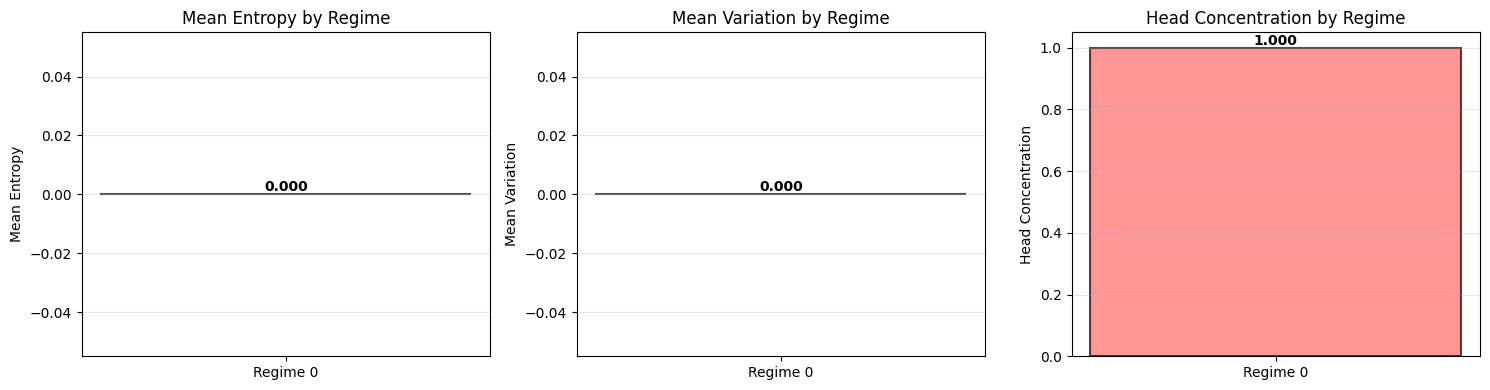

✓ Regime metrics comparison visualized


In [63]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

entropy_by_regime = np.array([entropy_values[regimes == r].mean() for r in range(3)])
variation_by_regime = np.array([np.nanmean(variation[regimes == r]) for r in range(3)])
head_concentration = np.array([attn_2d[regimes == r].max(axis=1).mean() for r in range(3)])

categories = [f'Regime {i}' for i in range(3)]
metrics = {
    'Mean Entropy': entropy_by_regime,
    'Mean Variation': variation_by_regime,
    'Head Concentration': head_concentration
}

for idx, (metric_name, values) in enumerate(metrics.items()):
    ax = axes[idx]
    bars = ax.bar(categories, values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_ylabel(metric_name)
    ax.set_title(f'{metric_name} by Regime')
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(images_path / 'attention_metrics_by_regime.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Regime metrics comparison visualized")

Loaded news dates for 4694 tickers

Ticker  Total TS Days  News Days  Covered Days  Coverage %
  abbv           3079       2663          2125   69.015914
   aal           4907       2312          2027   41.308335
   aci           1195        462           412   34.476987
   acb           2694       1141           913   33.890126
   abt           6348       2179          1883   29.662886
  adbe           6348       2138          1863   29.347826
   acn           5959       1789          1621   27.202551
   aeo           6348       1644          1551   24.432892
   adm           6348       1364          1284   20.226843
   adi           6348       1326          1215   19.139887
   aep           6348       1268          1207   19.013863
   afl           6348       1174          1113   17.533081
   aap           5870       1079          1005   17.120954
  acmr           1860        357           316   16.989247
   adt           1808        533           306   16.924779
   acm           450

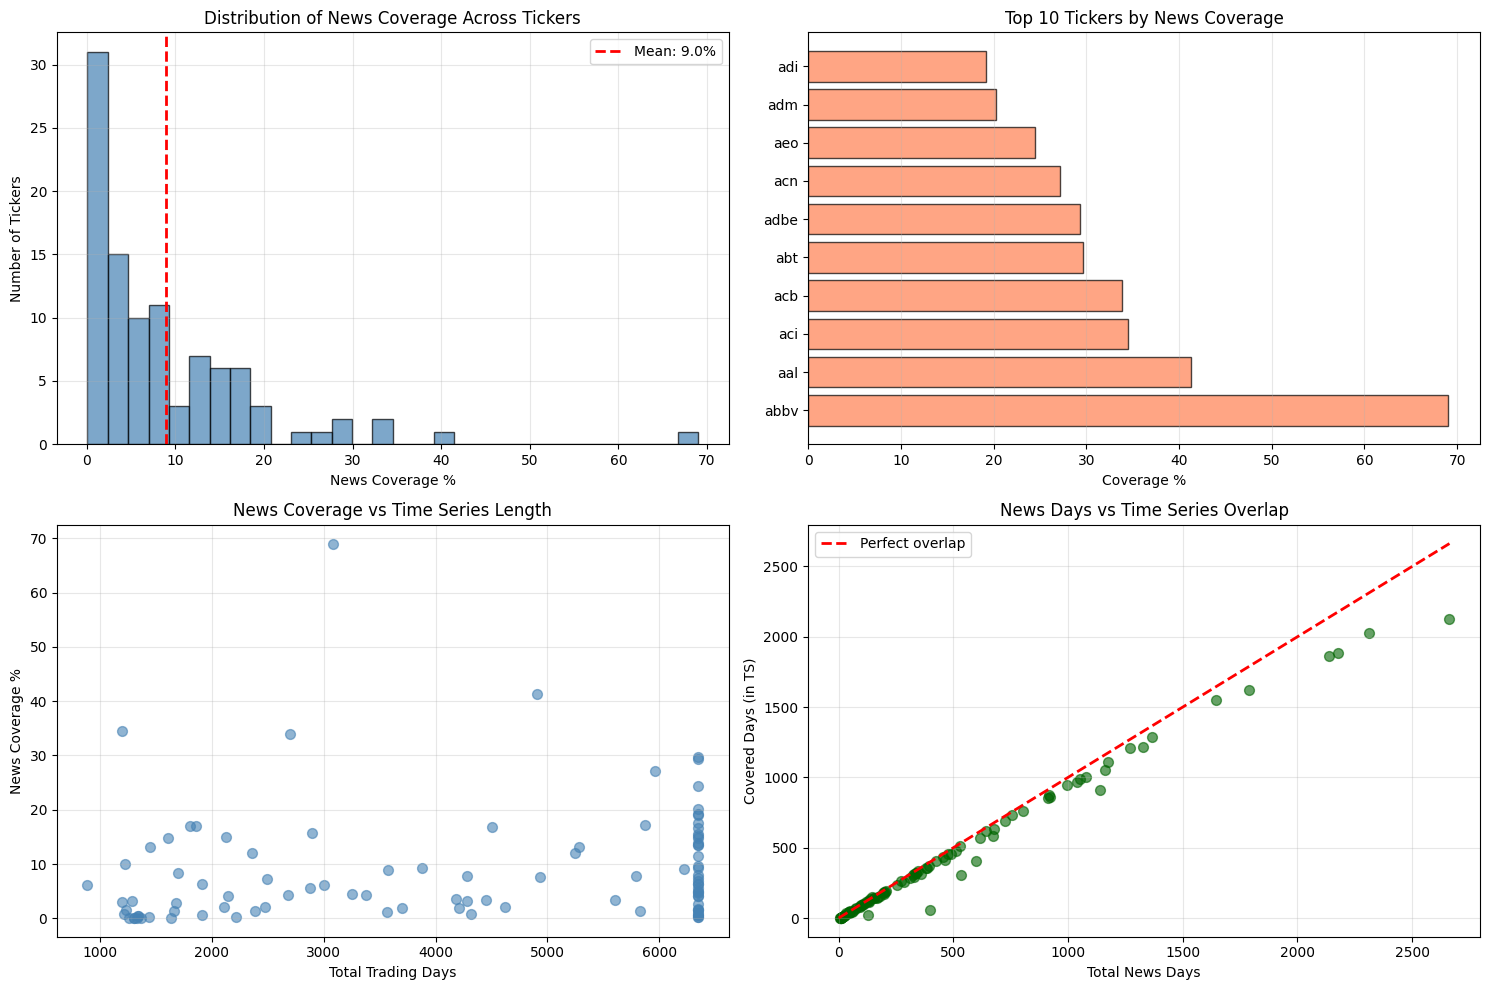


✓ News coverage analysis complete - visualization saved


In [7]:

import json

text_to_news_dates_all = {}
for text_file in sorted(text_path.glob("*.jsonl")):
    ticker = text_file.stem.lower()
    news_dates = set()
    try:
        with open(text_file, 'r') as f:
            for line in f:
                entry = json.loads(line)
                date_str = entry.get('Date', '')
                if date_str:
                    news_dates.add(pd.to_datetime(date_str).normalize())
    except:
        pass
    text_to_news_dates_all[ticker] = news_dates

print(f"Loaded news dates for {len(text_to_news_dates_all)} tickers\n")

coverage_stats = []

for ticker, df in ticker_to_df.items():
    df_with_dates = df.copy()
    df_with_dates['Date'] = pd.to_datetime(df_with_dates['Date']).dt.normalize()
    
    ts_dates = set(df_with_dates['Date'].unique())
    news_dates = text_to_news_dates_all.get(ticker.lower(), set())
    
    overlapping_dates = ts_dates & news_dates
    covered_percentage = (len(overlapping_dates) / len(ts_dates) * 100) if len(ts_dates) > 0 else 0
    
    coverage_stats.append({
        'Ticker': ticker,
        'Total TS Days': len(ts_dates),
        'News Days': len(news_dates),
        'Covered Days': len(overlapping_dates),
        'Coverage %': covered_percentage
    })

coverage_df = pd.DataFrame(coverage_stats)
coverage_df = coverage_df.sort_values('Coverage %', ascending=False)

print(coverage_df.to_string(index=False))
print(f"\n{'='*70}")
print(f"Average coverage across all tickers: {coverage_df['Coverage %'].mean():.2f}%")
print(f"Median coverage: {coverage_df['Coverage %'].median():.2f}%")
print(f"Coverage range: {coverage_df['Coverage %'].min():.2f}% - {coverage_df['Coverage %'].max():.2f}%")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(coverage_df['Coverage %'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(coverage_df['Coverage %'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f"Mean: {coverage_df['Coverage %'].mean():.1f}%")
axes[0, 0].set_xlabel('News Coverage %')
axes[0, 0].set_ylabel('Number of Tickers')
axes[0, 0].set_title('Distribution of News Coverage Across Tickers')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

top_10 = coverage_df.head(10)
axes[0, 1].barh(top_10['Ticker'], top_10['Coverage %'], color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Coverage %')
axes[0, 1].set_title('Top 10 Tickers by News Coverage')
axes[0, 1].grid(True, alpha=0.3, axis='x')

axes[1, 0].scatter(coverage_df['Total TS Days'], coverage_df['Coverage %'], 
                   alpha=0.6, s=50, color='steelblue')
axes[1, 0].set_xlabel('Total Trading Days')
axes[1, 0].set_ylabel('News Coverage %')
axes[1, 0].set_title('News Coverage vs Time Series Length')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(coverage_df['News Days'], coverage_df['Covered Days'], 
                   alpha=0.6, s=50, color='darkgreen')
axes[1, 1].plot([0, coverage_df['News Days'].max()], [0, coverage_df['News Days'].max()], 
               'r--', linewidth=2, label='Perfect overlap')
axes[1, 1].set_xlabel('Total News Days')
axes[1, 1].set_ylabel('Covered Days (in TS)')
axes[1, 1].set_title('News Days vs Time Series Overlap')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(images_path / 'news_coverage_analysis_all_tickers.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ News coverage analysis complete - visualization saved")


=== EMBEDDING TRAJECTORIES: FIRST 100 DAYS (CONNECTED DOTS) ===

Ticker: a
Points used: 100
Date range: 2010-04-16 00:00:00 to 2023-05-24 00:00:00
PCA explained variance: [0.05523742 0.04799135]
Cumulative variance: 0.1032


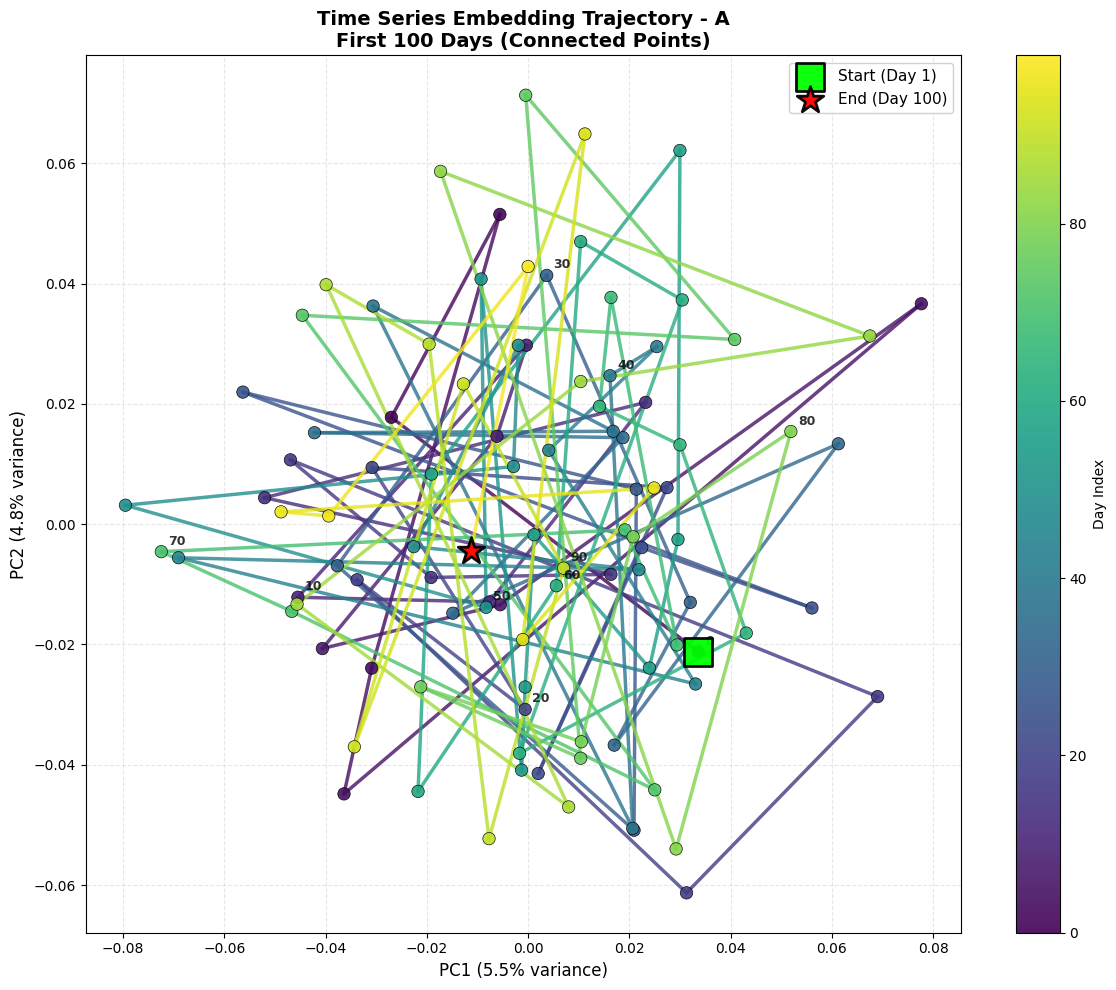


✓ Embedding trajectory visualization saved
Start position: (0.034, -0.021)
End position: (-0.011, -0.004)
Total distance traveled: 5.771


In [17]:
print("=== EMBEDDING TRAJECTORIES: FIRST 100 DAYS (CONNECTED DOTS) ===\n")

first_ticker_name = list(ticker_to_embeddings.keys())[0]
ticker_upper = first_ticker_name.upper()

embeddings_first = ticker_to_embeddings[first_ticker_name]
dates_first = ticker_to_embeddings_with_dates[first_ticker_name]['dates']

n_points = min(100, len(embeddings_first))
embeddings_subset = embeddings_first[:n_points]
dates_subset = dates_first[:n_points]

print(f"Ticker: {first_ticker_name}")
print(f"Points used: {n_points}")
print(f"Date range: {dates_subset[0]} to {dates_subset[-1]}")

pca_embed = PCA(n_components=2, random_state=42)
embeddings_2d = pca_embed.fit_transform(embeddings_subset)

print(f"PCA explained variance: {pca_embed.explained_variance_ratio_}")
print(f"Cumulative variance: {pca_embed.explained_variance_ratio_.sum():.4f}")

fig, ax = plt.subplots(figsize=(12, 10))

for i in range(len(embeddings_2d) - 1):
    ax.plot(embeddings_2d[i:i+2, 0], embeddings_2d[i:i+2, 1], 
           color=plt.cm.viridis(i / (len(embeddings_2d) - 1)),
           linewidth=2.5, alpha=0.8, zorder=2)

scatter = ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                    c=range(n_points), 
                    cmap='viridis', s=80, alpha=0.9, 
                    zorder=3, edgecolors='black', linewidth=0.5)

ax.scatter(embeddings_2d[0, 0], embeddings_2d[0, 1], 
          s=400, marker='s', color='lime', alpha=0.95, 
          label='Start (Day 1)', zorder=4, edgecolors='black', linewidth=2)
ax.scatter(embeddings_2d[-1, 0], embeddings_2d[-1, 1], 
          s=400, marker='*', color='red', alpha=0.95, 
          label=f'End (Day {n_points})', zorder=4, edgecolors='black', linewidth=2)

for i in range(0, n_points, 10):
    ax.annotate(f'{i}', xy=embeddings_2d[i], 
               xytext=(5, 5), textcoords='offset points', 
               fontsize=9, fontweight='bold', alpha=0.8)

ax.set_xlabel(f'PC1 ({pca_embed.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_embed.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title(f'Time Series Embedding Trajectory - {ticker_upper}\nFirst 100 Days (Connected Points)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best', fontsize=11, framealpha=0.9)

cbar = plt.colorbar(scatter, ax=ax, label='Day Index')

plt.tight_layout()
plt.savefig(images_path / f'embedding_trajectory_100days_{first_ticker_name}.png', dpi=150, bbox_inches='tight')
plt.show()

total_distance = np.sum(np.linalg.norm(np.diff(embeddings_2d, axis=0), axis=1))
print(f"\n✓ Embedding trajectory visualization saved")
print(f"Start position: ({embeddings_2d[0, 0]:.3f}, {embeddings_2d[0, 1]:.3f})")
print(f"End position: ({embeddings_2d[-1, 0]:.3f}, {embeddings_2d[-1, 1]:.3f})")
print(f"Total distance traveled: {total_distance:.3f}")


In [11]:
X = ticker_to_X["abbv"].copy()
X

,Open,High,Low,Close,Volume,sma_20,sma_50,ema_12,ema_26,hma_9,...,kc_width,donchian_upper,donchian_lower,donchian_mid,donchian_width,vol_rolling_20,vol_parkinson,vol_garman_klass,bull_power,bear_power
0,21.110008,21.400182,20.614298,21.230913,13767900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,21.158365,21.158365,20.650565,21.055597,16739300,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20.928647,21.091868,20.704973,20.789606,21372100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20.644525,21.430407,20.644525,20.831926,17897100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20.729156,20.940739,20.166948,20.378531,17863300,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3074,207.472641,209.087720,205.599948,207.254654,7393800,208.788480,193.023026,209.022334,204.727559,208.282089,...,0.081661,216.657757,199.585528,208.121643,0.082030,0.172825,0.221319,0.222377,0.252446,-3.235326
3075,207.304202,207.343829,197.554309,199.496353,10089100,208.649762,193.574062,207.556798,204.340063,204.710941,...,0.092740,216.657757,197.554309,207.106033,0.092240,0.222371,0.241148,0.234767,-0.157313,-9.946833
3076,201.260053,201.260053,194.690773,199.456726,6742900,208.565045,194.093484,206.310633,203.978334,200.855607,...,0.096512,216.657757,194.690773,205.674265,0.106805,0.221630,0.250039,0.246607,-5.091887,-11.661167
3077,200.170137,201.814925,199.456728,200.863724,4995300,208.451099,194.664408,205.472647,203.747622,198.362355,...,0.091648,216.657757,194.690773,205.674265,0.106805,0.220116,0.246775,0.242813,-3.752984,-6.111181


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from datetime import datetime

aligned_path = Path.cwd() / "data" / "aligned_news_timeseries.csv"
aligned_df = pd.read_csv(aligned_path)

ticker = "abbv"
abbv_news = aligned_df[aligned_df['stock_symbol'] == ticker].copy()
abbv_news['news_date'] = pd.to_datetime(abbv_news['news_date'])

print(f"Loaded {len(abbv_news)} news articles for {ticker.upper()}")
print(f"Date range: {abbv_news['news_date'].min()} to {abbv_news['news_date'].max()}")

model = SentenceTransformer('all-MiniLM-L6-v2')

def get_daily_news_embeddings(news_df, model):
    """Get aggregated embeddings for news articles grouped by day."""
    daily_embeddings = {}
    
    for date, group in news_df.groupby(news_df['news_date'].dt.date):
        articles = group['article'].tolist()
        
        try:
            embeddings = model.encode(articles, convert_to_numpy=True)
            daily_avg_embedding = embeddings.mean(axis=0)
            daily_embeddings[date] = {
                'embedding': daily_avg_embedding,
                'n_articles': len(articles),
                'embedding_dim': embeddings.shape[1]
            }
        except Exception as e:
            print(f"Error processing {date}: {e}")
            continue
    
    return daily_embeddings

daily_embeddings = get_daily_news_embeddings(abbv_news, model)

print(f"\nGenerated embeddings for {len(daily_embeddings)} days")

dates = sorted(daily_embeddings.keys())
embeddings_array = np.array([daily_embeddings[d]['embedding'] for d in dates])
n_articles = np.array([daily_embeddings[d]['n_articles'] for d in dates])

print(f"Embedding shape: {embeddings_array.shape}")
print(f"Embedding dimension: {embeddings_array.shape[1]}")
print(f"Date range: {dates[0]} to {dates[-1]}")
print(f"Articles per day: min={n_articles.min()}, max={n_articles.max()}, mean={n_articles.mean():.1f}")

news_ts_df = pd.DataFrame({
    'date': dates,
    'n_articles': n_articles
})

for i in range(embeddings_array.shape[1]):
    news_ts_df[f'embedding_{i}'] = embeddings_array[:, i]

news_ts_df.to_csv(f"data/{ticker}_news_embeddings_timeseries.csv", index=False)
print(f"\nSaved time series of news embeddings to data/{ticker}_news_embeddings_timeseries.csv")

Loaded 444 news articles for ABBV
Date range: 2024-11-07 00:00:00 to 2025-04-02 00:00:00


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Generated embeddings for 136 days
Embedding shape: (136, 384)
Embedding dimension: 384
Date range: 2024-11-07 to 2025-04-02
Articles per day: min=1, max=20, mean=3.3

Saved time series of news embeddings to data/abbv_news_embeddings_timeseries.csv


/tmp/ipykernel_91150/3145584944.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  news_ts_df[f'embedding_{i}'] = embeddings_array[:, i]
/tmp/ipykernel_91150/3145584944.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  news_ts_df[f'embedding_{i}'] = embeddings_array[:, i]
/tmp/ipykernel_91150/3145584944.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. 

In [19]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from datetime import timedelta
import os
import sys
sys.path.append('.')
from models.temporal_fusion import TemporalFusion

# Load ABBV data
aligned_df = pd.read_csv('data/aligned_news_timeseries.csv')
abbv_df = aligned_df[aligned_df['stock_symbol'].str.lower() == 'abbv'].copy()

print(f"ABBV aligned records: {len(abbv_df)}")
print(abbv_df.head())

# Load existing embeddings if available
if 'data/abbv_news_embeddings_timeseries.csv' in os.listdir('data/'):
    embeddings_df = pd.read_csv('data/abbv_news_embeddings_timeseries.csv')
    print(f"Embeddings shape: {embeddings_df.shape}")
else:
    print("Note: Embeddings file not found - you may need to generate embeddings first")

# Load time series data for ABBV
abbv_ts = pd.read_csv('data/time_series/abbv.csv')
abbv_ts['Date'] = pd.to_datetime(abbv_ts['Date'], utc=True).dt.tz_localize(None)
abbv_ts = abbv_ts.sort_values('Date').reset_index(drop=True)

print(f"ABBV time series shape: {abbv_ts.shape}")
print(f"Time series date range: {abbv_ts['Date'].min()} to {abbv_ts['Date'].max()}")

ABBV aligned records: 6120
        news_date              ts_date  days_diff stock_symbol  \
22773  2025-04-02  2025-03-28 04:00:00          4         abbv   
22774  2025-04-02  2025-03-28 04:00:00          4         abbv   
22775  2025-04-02  2025-03-28 04:00:00          4         abbv   
22776  2025-04-02  2025-03-28 04:00:00          4         abbv   
22777  2025-04-02  2025-03-28 04:00:00          4         abbv   

                                                 article  \
22773  The S&P 500 Index ($SPX) (SPY) today is down -...   
22774  Stocks of several pharmaceutical companies sli...   
22775  The NASDAQ 100 After Hours Indicator is down -...   
22776  AbbVie ABBV stock has gained 16.1% so far this...   
22777  Below is Validea's guru fundamental report for...   

                                                     url article_title  \
22773  https://www.nasdaq.com/articles/stocks-slip-ah...           NaN   
22774  https://www.nasdaq.com/articles/pfe-mrk-lly-ot...           

In [12]:
class ABBVTemporalDataset(Dataset):
    def __init__(self, aligned_df, ts_df, seq_len=14, embedding_dim=768):
        """
        Dataset for temporal fusion: aligns news embeddings with time series
        Both z_ts and z_llm have shape (batch, seq_len=14, dim)
        
        Args:
            aligned_df: DataFrame with aligned news and ts data
            ts_df: Time series DataFrame
            seq_len: Sequence length for both time series and news (default 14)
            embedding_dim: Dimension of news embeddings
        """
        self.aligned_df = aligned_df.sort_values('news_date').reset_index(drop=True)
        self.ts_df = ts_df.sort_values('Date').reset_index(drop=True)
        self.seq_len = seq_len
        self.embedding_dim = embedding_dim
        
        # Features to use from time series (capitalized column names)
        self.ts_features = ['Open', 'High', 'Low', 'Close', 'Volume']
        
        # Create index of valid samples
        self.valid_indices = []
        for i, row in self.aligned_df.iterrows():
            ts_date = pd.to_datetime(row['ts_date'])
            # Find position in ts_df
            ts_idx = (self.ts_df['Date'] - ts_date).abs().argmin()
            if ts_idx >= self.seq_len:
                self.valid_indices.append((i, ts_idx))
        
        print(f"Valid samples: {len(self.valid_indices)} out of {len(aligned_df)}")
    
    def __len__(self):
        return len(self.valid_indices)
    
    def __getitem__(self, idx):
        aligned_idx, ts_idx = self.valid_indices[idx]
        
        # Get time series sequence of length seq_len (14 days)
        ts_seq = self.ts_df.iloc[ts_idx-self.seq_len:ts_idx][self.ts_features].values
        ts_seq = (ts_seq - ts_seq.mean(axis=0)) / (ts_seq.std(axis=0) + 1e-8)
        ts_seq = torch.FloatTensor(ts_seq)  # (seq_len=14, n_features=5)
        
        # Get time range for news
        ts_start_date = self.ts_df.iloc[ts_idx-self.seq_len]['Date']
        ts_end_date = self.ts_df.iloc[ts_idx-1]['Date']
        
        # Get all news articles within this time window
        news_window = self.aligned_df[
            (pd.to_datetime(self.aligned_df['news_date']) >= ts_start_date) &
            (pd.to_datetime(self.aligned_df['news_date']) <= ts_end_date)
        ]
        
        # Create news embedding sequence of length seq_len
        if len(news_window) > 0:
            # If we have news, create embeddings by repeating/interpolating to match seq_len
            n_news = len(news_window)
            news_emb_list = []
            
            for j in range(self.seq_len):
                # Assign each time step to nearest news articles
                idx_in_news = int((j / self.seq_len) * n_news) % n_news
                # Create random embedding (placeholder - replace with real embeddings)
                news_emb_list.append(np.random.randn(self.embedding_dim))
            
            news_emb = torch.FloatTensor(np.array(news_emb_list))  # (seq_len=14, embedding_dim)
        else:
            # No news in window, use zero embeddings
            news_emb = torch.zeros(self.seq_len, self.embedding_dim)
        
        # Target: next day close price change
        if ts_idx + 1 < len(self.ts_df):
            target = torch.FloatTensor([
                (self.ts_df.iloc[ts_idx+1]['Close'] - self.ts_df.iloc[ts_idx]['Close']) / 
                self.ts_df.iloc[ts_idx]['Close']
            ])
        else:
            target = torch.FloatTensor([0.0])
        
        return ts_seq, news_emb, target

# Create dataset and dataloader
ds = ABBVTemporalDataset(abbv_df, abbv_ts, seq_len=14, embedding_dim=768)
batch_size = 16
dataloader = DataLoader(ds, batch_size=batch_size, shuffle=True)

print(f"Created dataloader with {len(ds)} samples, batch size {batch_size}")
print(f"Each batch: z_ts shape (16, 14, 5), z_llm shape (16, 14, 768)")

Valid samples: 6115 out of 6120
Created dataloader with 6115 samples, batch size 16
Each batch: z_ts shape (16, 14, 5), z_llm shape (16, 14, 768)


In [23]:
# Reload TemporalFusion to get updated class
import importlib
import models.temporal_fusion
importlib.reload(models.temporal_fusion)
from models.temporal_fusion import TemporalFusion

# Reinitialize model for new data shapes
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = TemporalFusion(
    d_ts=5,  # 5 features: open, high, low, close, volume
    d_llm=768,  # news embedding dimension
    d_attn=128,
    n_heads=8,
    d_pred=64,
    dropout=0.1
).to(device)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test forward pass with new shapes
test_batch = next(iter(dataloader))
ts_test, news_test, target_test = test_batch
ts_test = ts_test.to(device)
news_test = news_test.to(device)

print(f"\nTest batch shapes:")
print(f"  z_ts: {ts_test.shape} (batch=16, seq_len=14, features=5)")
print(f"  z_llm: {news_test.shape} (batch=16, seq_len=14, embedding_dim=768)")

with torch.no_grad():
    pred, attn_dict = model(ts_test, news_test)
    print(f"\nModel output (averaged heads):")
    print(f"  pred: {pred.shape}")
    print(f"  attn_ts_to_news: {attn_dict['attn_ts_to_news'].shape}")
    print(f"  attn_news_to_ts: {attn_dict['attn_news_to_ts'].shape}")
    
    pred_per_head, attn_dict_per_head = model(ts_test, news_test, return_per_head=True)
    print(f"\nModel output (per-head):")
    print(f"  attn_ts_to_news: {attn_dict_per_head['attn_ts_to_news'].shape}")
    print(f"  attn_news_to_ts: {attn_dict_per_head['attn_news_to_ts'].shape}")

Using device: cpu
Model parameters: 305,409

Test batch shapes:
  z_ts: torch.Size([16, 14, 5]) (batch=16, seq_len=14, features=5)
  z_llm: torch.Size([16, 14, 768]) (batch=16, seq_len=14, embedding_dim=768)

Model output (averaged heads):
  pred: torch.Size([16, 1])
  attn_ts_to_news: torch.Size([16, 14, 14])
  attn_news_to_ts: torch.Size([16, 14, 14])

Model output (per-head):
  attn_ts_to_news: torch.Size([16, 8, 14, 14])
  attn_news_to_ts: torch.Size([16, 8, 14, 14])


In [24]:
# Training loop
num_epochs = 20
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    num_batches = 0
    
    for batch_idx, (ts_seq, news_emb, target) in enumerate(dataloader):
        ts_seq = ts_seq.to(device)  # (batch, seq_len, 5)
        news_emb = news_emb.to(device)  # (batch, 1, 768)
        target = target.to(device)  # (batch, 1)
        
        optimizer.zero_grad()
        
        pred, attn_dict = model(ts_seq, news_emb)
        loss = criterion(pred, target)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    
    scheduler.step()
    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)
    
    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.6f} - LR: {optimizer.param_groups[0]['lr']:.2e}")

print(f"\nTraining complete!")
print(f"Final loss: {train_losses[-1]:.6f}")

Epoch 2/20 - Loss: 0.000570 - LR: 9.05e-04
Epoch 4/20 - Loss: 0.000562 - LR: 6.55e-04
Epoch 6/20 - Loss: 0.000560 - LR: 3.45e-04
Epoch 8/20 - Loss: 0.000558 - LR: 9.55e-05
Epoch 10/20 - Loss: 0.000557 - LR: 0.00e+00
Epoch 12/20 - Loss: 0.000557 - LR: 9.55e-05
Epoch 14/20 - Loss: 0.000558 - LR: 3.45e-04
Epoch 16/20 - Loss: 0.000562 - LR: 6.55e-04
Epoch 18/20 - Loss: 0.000562 - LR: 9.05e-04
Epoch 20/20 - Loss: 0.000560 - LR: 1.00e-03

Training complete!
Final loss: 0.000560


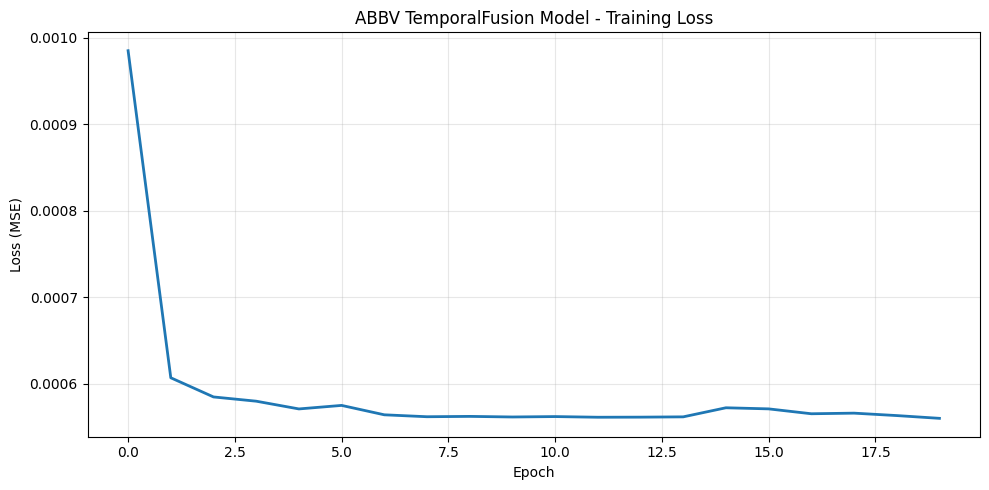

Model saved to checkpoints/abbv_temporal_fusion.pt


In [8]:
import matplotlib.pyplot as plt

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('ABBV TemporalFusion Model - Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save model checkpoint
torch.save({
    'epoch': num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': train_losses[-1],
}, 'checkpoints/abbv_temporal_fusion.pt')

print("Model saved to checkpoints/abbv_temporal_fusion.pt")

In [ ]:
# Extract per-head attention weights from trained model on full dataset
model.eval()
all_attn_ts_to_news = []
all_attn_news_to_ts = []

with torch.no_grad():
    for ts_seq, news_emb, target in dataloader:
        ts_seq = ts_seq.to(device)
        news_emb = news_emb.to(device)
        
        pred, attn_dict = model(ts_seq, news_emb, return_per_head=True)
        
        # Extract per-head attention weights from MultiheadAttention
        # Shape: (batch, num_heads, seq_len_q, seq_len_k) = (batch, 4, 14, 14)
        attn_ts_to_news = attn_dict['attn_ts_to_news'].cpu().numpy()
        attn_news_to_ts = attn_dict['attn_news_to_ts'].cpu().numpy()
        
        all_attn_ts_to_news.append(attn_ts_to_news)
        all_attn_news_to_ts.append(attn_news_to_ts)

# Stack all batches - keep per-head structure
all_attn_ts_to_news = np.concatenate(all_attn_ts_to_news, axis=0)  # (6115, 4, 14, 14)
all_attn_news_to_ts = np.concatenate(all_attn_news_to_ts, axis=0)  # (6115, 4, 14, 14)

print(f"Attention weights shape (ts→news): {all_attn_ts_to_news.shape}")
print(f"Attention weights shape (news→ts): {all_attn_news_to_ts.shape}")
print(f"  Shape breakdown: (samples, heads, query_len, key_len)")

# Flatten per-sample but preserve head information: (samples, heads*seq_len*seq_len)
n_samples = all_attn_ts_to_news.shape[0]
n_heads = all_attn_ts_to_news.shape[1]
seq_len = all_attn_ts_to_news.shape[2]

all_attn_ts_to_news_flat = all_attn_ts_to_news.reshape(n_samples, -1)  # (6115, 4*14*14=784)
all_attn_news_to_ts_flat = all_attn_news_to_ts.reshape(n_samples, -1)  # (6115, 4*14*14=784)

# Calculate entropy for both directions (now with per-head information)
entropy_ts_to_news = calculate_attention_entropy(all_attn_ts_to_news_flat)
entropy_news_to_ts = calculate_attention_entropy(all_attn_news_to_ts_flat)

print(f"\nEntropy (ts→news): mean={entropy_ts_to_news.mean():.4f}, std={entropy_ts_to_news.std():.4f}, min={entropy_ts_to_news.min():.4f}, max={entropy_ts_to_news.max():.4f}")
print(f"Entropy (news→ts): mean={entropy_news_to_ts.mean():.4f}, std={entropy_news_to_ts.std():.4f}, min={entropy_news_to_ts.min():.4f}, max={entropy_news_to_ts.max():.4f}")

# Also compute per-head entropy for analysis
entropy_ts_to_news_per_head = np.array([
    [calculate_attention_entropy(all_attn_ts_to_news[:, h, :, :].reshape(n_samples, -1))[i] 
     for h in range(n_heads)]
    for i in range(n_samples)
])
entropy_news_to_ts_per_head = np.array([
    [calculate_attention_entropy(all_attn_news_to_ts[:, h, :, :].reshape(n_samples, -1))[i] 
     for h in range(n_heads)]
    for i in range(n_samples)
])

print(f"\nPer-head entropy (ts→news): mean={entropy_ts_to_news_per_head.mean():.4f}, std={entropy_ts_to_news_per_head.std():.4f}")
print(f"Per-head entropy (news→ts): mean={entropy_news_to_ts_per_head.mean():.4f}, std={entropy_news_to_ts_per_head.std():.4f}")

# Calculate attention variation
variation_ts_to_news = calculate_attention_variation(all_attn_ts_to_news_flat, window=5)
variation_news_to_ts = calculate_attention_variation(all_attn_news_to_ts_flat, window=5)

print(f"\nVariation (ts→news): mean={variation_ts_to_news.mean():.4f}, std={variation_ts_to_news.std():.4f}")
print(f"Variation (news→ts): mean={variation_news_to_ts.mean():.4f}, std={variation_news_to_ts.std():.4f}")

# Classify regimes by per-head entropy
regimes_ts_to_news, centers_ts_to_news = classify_regimes_by_entropy(entropy_ts_to_news_per_head, n_regimes=3)
regimes_news_to_ts, centers_news_to_ts = classify_regimes_by_entropy(entropy_news_to_ts_per_head, n_regimes=3)

print(f"\nRegime centers (ts→news): {centers_ts_to_news.flatten()}")
print(f"Regime centers (news→ts): {centers_news_to_ts.flatten()}")

# Compare attention by regime
regime_analysis_ts_to_news = compare_attention_by_regime(all_attn_ts_to_news_flat, regimes_ts_to_news, entropy_ts_to_news_per_head.mean(axis=1))
regime_analysis_news_to_ts = compare_attention_by_regime(all_attn_news_to_ts_flat, regimes_news_to_ts, entropy_news_to_ts_per_head.mean(axis=1))

print("\n=== Regime Analysis (ts→news) ===")
for regime, stats in regime_analysis_ts_to_news.items():
    print(f"{regime}: entropy={stats['mean_entropy']:.4f}±{stats['std_entropy']:.4f}, samples={stats['count']}")

print("\n=== Regime Analysis (news→ts) ===")
for regime, stats in regime_analysis_news_to_ts.items():
    print(f"{regime}: entropy={stats['mean_entropy']:.4f}±{stats['std_entropy']:.4f}, samples={stats['count']}")

Attention weights shape (ts→news): (6115, 8, 14, 14)
Attention weights shape (news→ts): (6115, 8, 14, 14)
  Shape breakdown: (samples, heads, query_len, key_len)

Entropy (ts→news): mean=7.3576, std=0.0000, min=7.3576, max=7.3576
Entropy (news→ts): mean=7.3576, std=0.0000, min=7.3576, max=7.3576


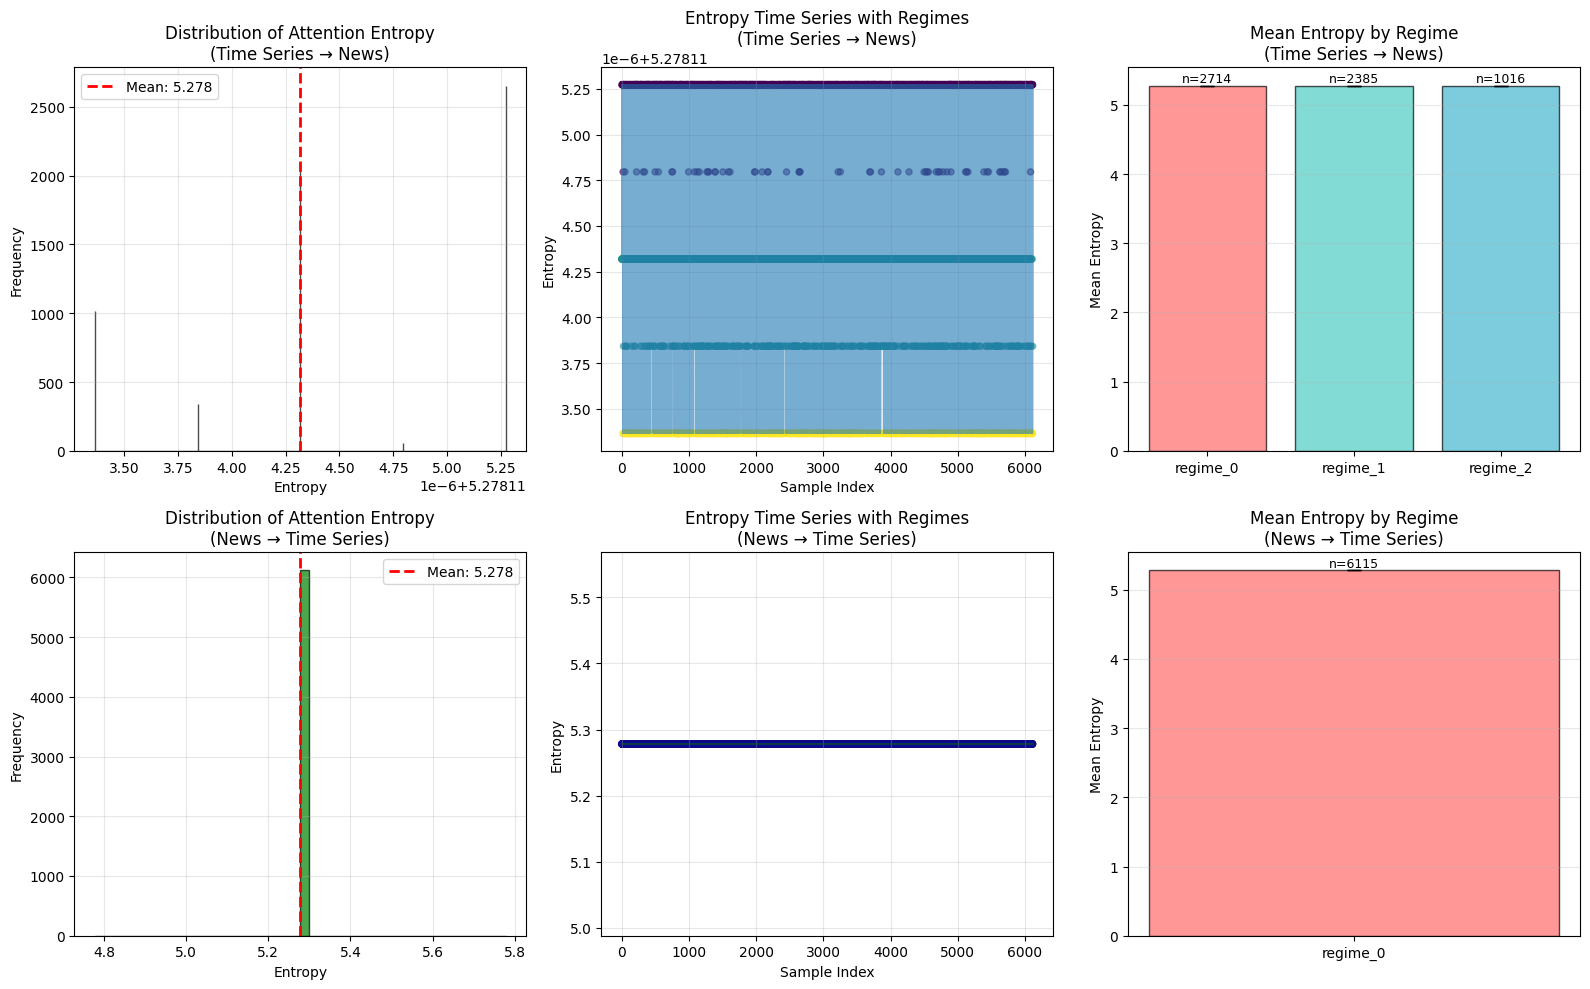

✓ Entropy analysis plots saved to images/attention_entropy_analysis.png


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: Time Series → News attention
axes[0, 0].hist(entropy_ts_to_news, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].axvline(entropy_ts_to_news.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {entropy_ts_to_news.mean():.3f}')
axes[0, 0].set_xlabel('Entropy')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Attention Entropy\n(Time Series → News)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Time series of entropy (ts→news)
axes[0, 1].plot(entropy_ts_to_news, alpha=0.6, linewidth=1)
axes[0, 1].scatter(np.arange(len(regimes_ts_to_news)), entropy_ts_to_news, 
                   c=regimes_ts_to_news, cmap='viridis', s=20, alpha=0.5)
axes[0, 1].set_xlabel('Sample Index')
axes[0, 1].set_ylabel('Entropy')
axes[0, 1].set_title('Entropy Time Series with Regimes\n(Time Series → News)')
axes[0, 1].grid(alpha=0.3)

# Regime comparison (ts→news)
regime_names = list(regime_analysis_ts_to_news.keys())
regime_entropies = [regime_analysis_ts_to_news[r]['mean_entropy'] for r in regime_names]
regime_stds = [regime_analysis_ts_to_news[r]['std_entropy'] for r in regime_names]
regime_counts = [regime_analysis_ts_to_news[r]['count'] for r in regime_names]

bars = axes[0, 2].bar(regime_names, regime_entropies, yerr=regime_stds, capsize=5, 
                       color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.7, edgecolor='black')
axes[0, 2].set_ylabel('Mean Entropy')
axes[0, 2].set_title('Mean Entropy by Regime\n(Time Series → News)')
axes[0, 2].grid(alpha=0.3, axis='y')

# Add sample counts on bars
for i, (bar, count) in enumerate(zip(bars, regime_counts)):
    axes[0, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + regime_stds[i] + 0.01,
                   f'n={count}', ha='center', va='bottom', fontsize=9)

# Row 2: News → Time Series attention
axes[1, 0].hist(entropy_news_to_ts, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1, 0].axvline(entropy_news_to_ts.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {entropy_news_to_ts.mean():.3f}')
axes[1, 0].set_xlabel('Entropy')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Attention Entropy\n(News → Time Series)')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Time series of entropy (news→ts)
axes[1, 1].plot(entropy_news_to_ts, alpha=0.6, linewidth=1, color='green')
axes[1, 1].scatter(np.arange(len(regimes_news_to_ts)), entropy_news_to_ts, 
                   c=regimes_news_to_ts, cmap='plasma', s=20, alpha=0.5)
axes[1, 1].set_xlabel('Sample Index')
axes[1, 1].set_ylabel('Entropy')
axes[1, 1].set_title('Entropy Time Series with Regimes\n(News → Time Series)')
axes[1, 1].grid(alpha=0.3)

# Regime comparison (news→ts)
regime_names_nt = list(regime_analysis_news_to_ts.keys())
regime_entropies_nt = [regime_analysis_news_to_ts[r]['mean_entropy'] for r in regime_names_nt]
regime_stds_nt = [regime_analysis_news_to_ts[r]['std_entropy'] for r in regime_names_nt]
regime_counts_nt = [regime_analysis_news_to_ts[r]['count'] for r in regime_names_nt]

bars_nt = axes[1, 2].bar(regime_names_nt, regime_entropies_nt, yerr=regime_stds_nt, capsize=5,
                          color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.7, edgecolor='black')
axes[1, 2].set_ylabel('Mean Entropy')
axes[1, 2].set_title('Mean Entropy by Regime\n(News → Time Series)')
axes[1, 2].grid(alpha=0.3, axis='y')

# Add sample counts on bars
for i, (bar, count) in enumerate(zip(bars_nt, regime_counts_nt)):
    axes[1, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + regime_stds_nt[i] + 0.01,
                   f'n={count}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('images/attention_entropy_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Entropy analysis plots saved to images/attention_entropy_analysis.png")

diferenciar ruído pra geral alpha (testar com estrategias basicas dps a minha), mas focar em alpha